In [1]:
# Load libraries

library(TCGAbiolinks)
library(dplyr)
library(purrr)
library(DT)
library(SummarizedExperiment)
library(sesame)
library(sesameData)
library(janitor)
library(maftools)
library(survival)
library(survminer)

# Parallel processing
library(future.apply)
plan(multisession)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘matrixStats’


The following object is masked from ‘package:dplyr’:

    count



Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPer

In [2]:
# https://bioconductor.org/packages/release/bioc/vignettes/TCGAbiolinks/inst/doc/download_prepare.html
# Arguments
# GDCdownload
# GDCquery
# GDCprepare

In [3]:
print("Download the clinical data : for all patients")

# -------------------------------------------
# Step 1: Query and download BCR Biotab clinical data
# -------------------------------------------
query <- GDCquery(
  project = "TCGA-OV", 
  data.category = "Clinical",
  data.type = "Clinical Supplement", 
  data.format = "BCR Biotab"
)

GDCdownload(query)
clinical_tab_all <- GDCprepare(query)

# -------------------------------------------
# Step 2: Explore available clinical tables
# -------------------------------------------
cat("Clinical tables available in TCGA-OV Biotab:\n")
print(names(clinical_tab_all))

# -------------------------------------------
# Step 3: Extract tables of interest
# -------------------------------------------
clinical_patient <- clinical_tab_all[["clinical_patient_ov"]]
clinical_follow_up <- clinical_tab_all[["clinical_follow_up_v1.0_ov"]]

clinical_drug <- clinical_tab_all[["clinical_drug_ov"]]

clinical_radiation <- clinical_tab_all[["clinical_radiation_ov"]]
clinical_omf <- clinical_tab_all[["clinical_omf_v4.0_ov"]]

clinical_nte <- clinical_tab_all[["clinical_nte_ov"]]
clinical_follow_up2 <- clinical_tab_all[["clinical_follow_up_v1.0_ov"]]

# Clinical tables available in TCGA-OV Biotab:
# [1] * "clinical_patient_ov"            * "clinical_nte_ov"               
# [3] * "clinical_drug_ov"               * "clinical_follow_up_v1.0_ov"    
# [5] * "clinical_follow_up_v1.0_nte_ov" * "clinical_radiation_ov"         
# [7] * "clinical_omf_v4.0_ov"    

[1] "Download the clinical data : for all patients"


--------------------------------------

o GDCquery: Searching in GDC database

--------------------------------------

Genome of reference: hg38

--------------------------------------------

oo Accessing GDC. This might take a while...

--------------------------------------------

ooo Project: TCGA-OV

--------------------

oo Filtering results

--------------------

ooo By data.format

ooo By data.type

----------------

oo Checking data

----------------

ooo Checking if there are duplicated cases


ooo Checking if there are results for the query

-------------------

o Preparing output

-------------------


Of the 7 files for download 7 already exist.

All samples have been already downloaded



  |======================================================================| 100%
Clinical tables available in TCGA-OV Biotab:
[1] "clinical_patient_ov"            "clinical_nte_ov"               
[3] "clinical_drug_ov"               "clinical_follow_up_v1.0_ov"    
[5] "clinical_follow_up_v1.0_nte_ov" "clinical_radiation_ov"         
[7] "clinical_omf_v4.0_ov"          


In [4]:
# list.files()

In [5]:
print("Survival Analysis")

[1] "Survival Analysis"


In [6]:
# Step 1: Query and download clinical data
query <- GDCquery(
  project = "TCGA-OV",
  data.category = "Clinical",
  data.type = "Clinical Supplement",
  data.format = "BCR Biotab",
  access = "open"
)
GDCdownload(query)
clinical_list <- GDCprepare(query)

# Step 2: Extract patient-level clinical data
clin.OV <- clinical_list$clinical_patient_OV

--------------------------------------

o GDCquery: Searching in GDC database

--------------------------------------

Genome of reference: hg38

--------------------------------------------

oo Accessing GDC. This might take a while...

--------------------------------------------

ooo Project: TCGA-OV

--------------------

oo Filtering results

--------------------

ooo By access

ooo By data.format

ooo By data.type

----------------

oo Checking data

----------------

ooo Checking if there are duplicated cases


ooo Checking if there are results for the query

-------------------

o Preparing output

-------------------


Of the 7 files for download 7 already exist.

All samples have been already downloaded



  |======================================================================| 100%


In [7]:
# Basic structure
# str(clinical_list)
# class(clinical_list)
# length(clinical_list)

# First few elements
# head(clinical_list)

# If it's a data frame
summary(clinical_list)
names(clinical_list)

clinical_list 

                               Length Class       Mode
clinical_patient_ov            57     spec_tbl_df list
clinical_nte_ov                10     spec_tbl_df list
clinical_drug_ov               28     spec_tbl_df list
clinical_follow_up_v1.0_ov     19     spec_tbl_df list
clinical_follow_up_v1.0_nte_ov 11     spec_tbl_df list
clinical_radiation_ov          18     spec_tbl_df list
clinical_omf_v4.0_ov           30     spec_tbl_df list

[1] "clinical_patient_ov"            "clinical_nte_ov"               
[3] "clinical_drug_ov"               "clinical_follow_up_v1.0_ov"    
[5] "clinical_follow_up_v1.0_nte_ov" "clinical_radiation_ov"         
[7] "clinical_omf_v4.0_ov"

bcr_patient_uuid,bcr_patient_barcode,form_completion_date,prospective_collection,retrospective_collection,gender,birth_days_to,race,ethnicity,jewish_religion_heritage_indicator,⋯,pathologic_M,pathologic_N,pathologic_T,pathologic_stage,patient_id,project_code,stage_other,system_version,tissue_source_site,tumor_tissue_site
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
bcr_patient_uuid,bcr_patient_barcode,form_completion_date,tissue_prospective_collection_indicator,tissue_retrospective_collection_indicator,gender,days_to_birth,race,ethnicity,jewish_origin,⋯,pathologic_M,pathologic_N,pathologic_T,pathologic_stage,patient_id,project_code,stage_other,system_version,tissue_source_site,tumor_tissue_site
CDE_ID:,CDE_ID:2003301,CDE_ID:,CDE_ID:3088492,CDE_ID:3088528,CDE_ID:2200604,CDE_ID:3008233,CDE_ID:2192199,CDE_ID:2192217,CDE_ID:2200537,⋯,CDE_ID:3045439,CDE_ID:3203106,CDE_ID:3045435,CDE_ID:3203222,CDE_ID:,CDE_ID:,CDE_ID:2007104,CDE_ID:2722309,CDE_ID:,CDE_ID:3427536
6d10d4ee-6331-4bba-93bc-a7b64cc0b22a,TCGA-04-1331,2009-3-26,[Not Available],[Not Available],FEMALE,-28848,WHITE,NOT HISPANIC OR LATINO,[Not Available],⋯,[Not Applicable],[Not Applicable],[Not Applicable],[Not Applicable],1331,[Not Available],[Not Available],[Not Available],04,Ovary
b46263ab-c3ca-4fda-a895-74c7e6e6fe22,TCGA-04-1332,2009-3-26,[Not Available],[Not Available],FEMALE,-25786,WHITE,NOT HISPANIC OR LATINO,[Not Available],⋯,[Not Applicable],[Not Applicable],[Not Applicable],[Not Applicable],1332,[Not Available],[Not Available],[Not Available],04,Ovary
ab3dbbbe-eed6-4a35-a505-1815225e86c9,TCGA-04-1335,2009-3-26,[Not Available],[Not Available],FEMALE,-21963,BLACK OR AFRICAN AMERICAN,NOT HISPANIC OR LATINO,[Not Available],⋯,[Not Applicable],[Not Applicable],[Not Applicable],[Not Applicable],1335,[Not Available],[Not Available],[Not Available],04,Ovary
538acb2a-c4ca-4656-a91c-841a42dbf15f,TCGA-04-1336,2009-5-11,[Not Available],[Not Available],FEMALE,-20271,WHITE,[Not Available],[Not Available],⋯,[Not Applicable],[Not Applicable],[Not Applicable],[Not Applicable],1336,[Not Available],[Not Available],[Not Available],04,Ovary
d1e974e7-dd68-40cc-ad06-2b57d964e5a1,TCGA-04-1337,2009-3-26,[Not Available],[Not Available],FEMALE,-28626,WHITE,NOT HISPANIC OR LATINO,[Not Available],⋯,[Not Applicable],[Not Applicable],[Not Applicable],[Not Applicable],1337,[Not Available],[Not Available],[Not Available],04,Ovary
31872f6a-d225-4f91-b38d-4505d19e406c,TCGA-04-1338,2009-7-14,[Not Available],[Not Available],FEMALE,-28789,WHITE,NOT HISPANIC OR LATINO,[Not Available],⋯,[Not Applicable],[Not Applicable],[Not Applicable],[Not Applicable],1338,[Not Available],[Not Available],[Not Available],04,Ovary
92badeb5-a50e-4a62-a67e-6a8a59c948ab,TCGA-04-1341,2009-3-26,NO,YES,FEMALE,-31215,WHITE,NOT HISPANIC OR LATINO,[Not Available],⋯,[Not Applicable],[Not Applicable],[Not Applicable],[Not Applicable],1341,[Not Available],[Not Available],[Not Available],04,Ovary


In [8]:
# Step 2: Extract patient-level clinical data
clin.OV <- clinical_list$clinical_patient_ov

In [9]:
head(clin.OV)
print(colnames(clin.OV))
print("dim size clinOV:")
dim(clin.OV)

bcr_patient_uuid,bcr_patient_barcode,form_completion_date,prospective_collection,retrospective_collection,gender,birth_days_to,race,ethnicity,jewish_religion_heritage_indicator,⋯,pathologic_M,pathologic_N,pathologic_T,pathologic_stage,patient_id,project_code,stage_other,system_version,tissue_source_site,tumor_tissue_site
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
bcr_patient_uuid,bcr_patient_barcode,form_completion_date,tissue_prospective_collection_indicator,tissue_retrospective_collection_indicator,gender,days_to_birth,race,ethnicity,jewish_origin,⋯,pathologic_M,pathologic_N,pathologic_T,pathologic_stage,patient_id,project_code,stage_other,system_version,tissue_source_site,tumor_tissue_site
CDE_ID:,CDE_ID:2003301,CDE_ID:,CDE_ID:3088492,CDE_ID:3088528,CDE_ID:2200604,CDE_ID:3008233,CDE_ID:2192199,CDE_ID:2192217,CDE_ID:2200537,⋯,CDE_ID:3045439,CDE_ID:3203106,CDE_ID:3045435,CDE_ID:3203222,CDE_ID:,CDE_ID:,CDE_ID:2007104,CDE_ID:2722309,CDE_ID:,CDE_ID:3427536
6d10d4ee-6331-4bba-93bc-a7b64cc0b22a,TCGA-04-1331,2009-3-26,[Not Available],[Not Available],FEMALE,-28848,WHITE,NOT HISPANIC OR LATINO,[Not Available],⋯,[Not Applicable],[Not Applicable],[Not Applicable],[Not Applicable],1331,[Not Available],[Not Available],[Not Available],04,Ovary
b46263ab-c3ca-4fda-a895-74c7e6e6fe22,TCGA-04-1332,2009-3-26,[Not Available],[Not Available],FEMALE,-25786,WHITE,NOT HISPANIC OR LATINO,[Not Available],⋯,[Not Applicable],[Not Applicable],[Not Applicable],[Not Applicable],1332,[Not Available],[Not Available],[Not Available],04,Ovary
ab3dbbbe-eed6-4a35-a505-1815225e86c9,TCGA-04-1335,2009-3-26,[Not Available],[Not Available],FEMALE,-21963,BLACK OR AFRICAN AMERICAN,NOT HISPANIC OR LATINO,[Not Available],⋯,[Not Applicable],[Not Applicable],[Not Applicable],[Not Applicable],1335,[Not Available],[Not Available],[Not Available],04,Ovary
538acb2a-c4ca-4656-a91c-841a42dbf15f,TCGA-04-1336,2009-5-11,[Not Available],[Not Available],FEMALE,-20271,WHITE,[Not Available],[Not Available],⋯,[Not Applicable],[Not Applicable],[Not Applicable],[Not Applicable],1336,[Not Available],[Not Available],[Not Available],04,Ovary


 [1] "bcr_patient_uuid"                    
 [2] "bcr_patient_barcode"                 
 [3] "form_completion_date"                
 [4] "prospective_collection"              
 [5] "retrospective_collection"            
 [6] "gender"                              
 [7] "birth_days_to"                       
 [8] "race"                                
 [9] "ethnicity"                           
[10] "jewish_religion_heritage_indicator"  
[11] "history_other_malignancy"            
[12] "history_neoadjuvant_treatment"       
[13] "initial_pathologic_dx_year"          
[14] "method_initial_path_dx"              
[15] "method_initial_path_dx_other"        
[16] "vital_status"                        
[17] "last_contact_days_to"                
[18] "death_days_to"                       
[19] "tumor_status"                        
[20] "tumor_grade"                         
[21] "residual_tumor"                      
[22] "residual_disease_largest_nodule"     
[23] "vascular_invasion_indicato

[1] 589  57

Warning message:
“There were 3 warnings in `mutate()`.
The first warning was:
ℹ In argument: `age = as.numeric(age_at_initial_pathologic_diagnosis)`.
Caused by warning:
! NAs introduced by coercion
ℹ Run `dplyr::last_dplyr_warnings()` to see the 2 remaining warnings.”
Warning message in .pvalue(fit, data = data, method = method, pval = pval, pval.coord = pval.coord, :
“There are no survival curves to be compared. 
 This is a null model.”


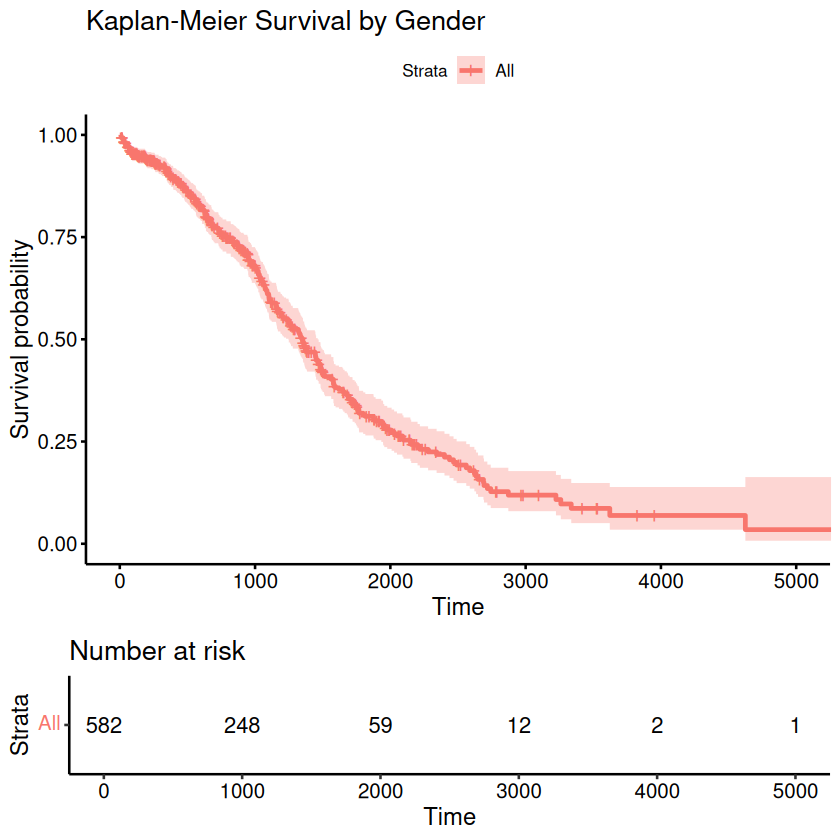


  [Discrepancy] [Not Available]      TUMOR FREE      WITH TUMOR 
              1              66             145             370 

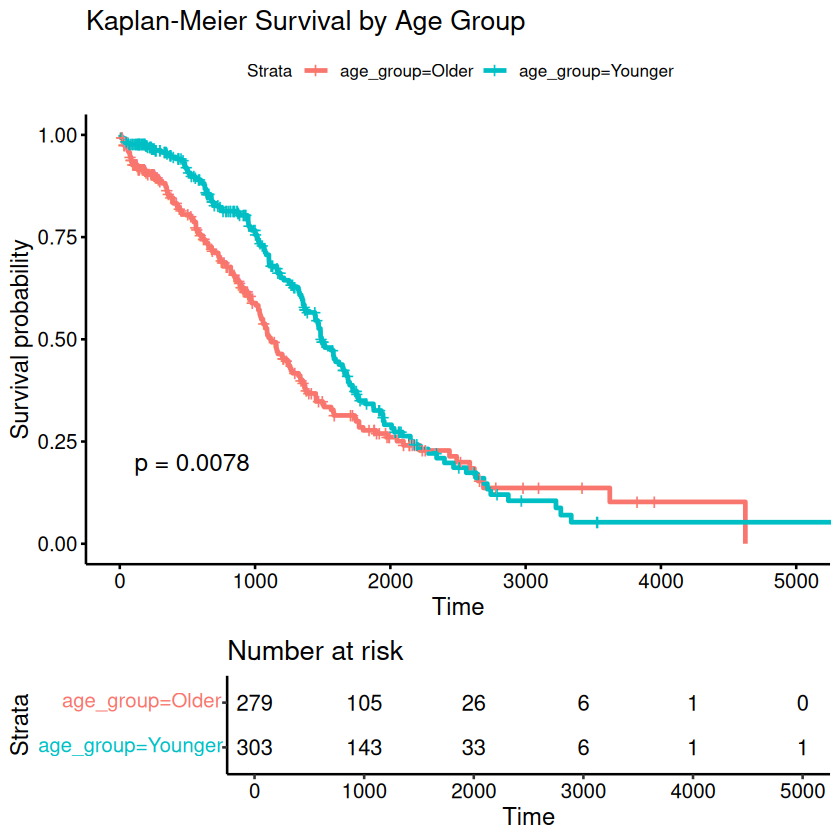

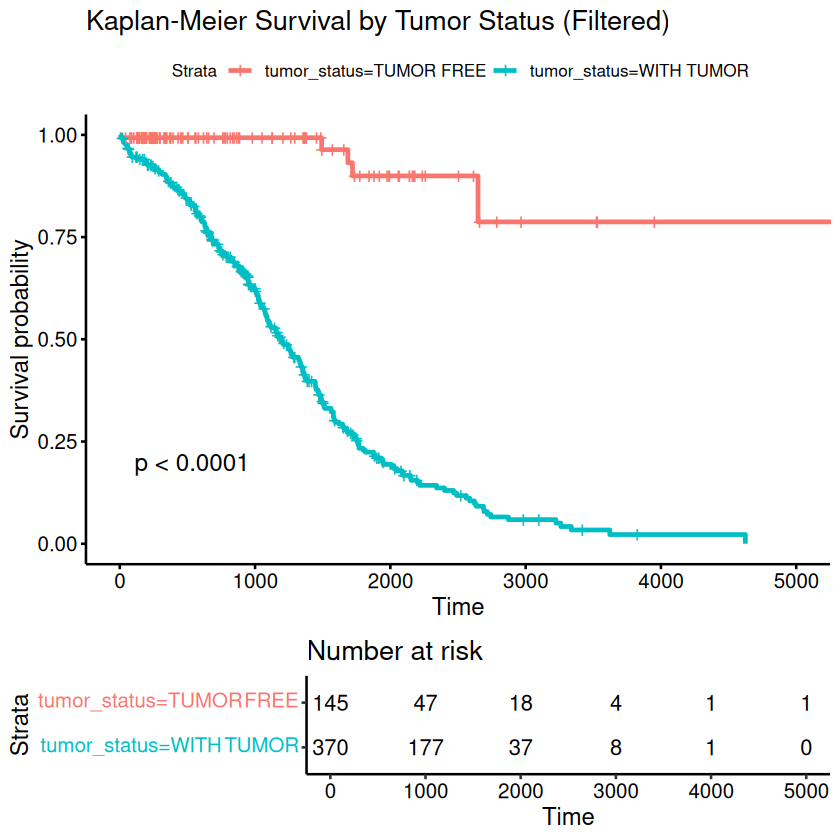

In [10]:
# If patient died: use days_to_death
# If patient is alive: use days_to_last_followup (censored observation)
# This creates a single time variable combining both scenarios.

# Clean and prepare data using actual column names
clin.OV <- clin.OV %>%
  filter(!is.na(gender), !is.na(vital_status)) %>%
  mutate(
    gender = as.character(gender),
    age = as.numeric(age_at_initial_pathologic_diagnosis),
    days_to_death = as.numeric(death_days_to),
    days_to_last_followup = as.numeric(last_contact_days_to),
    vital_status_bin = ifelse(vital_status == "Dead", 1, 0),
    time = ifelse(is.na(days_to_death), days_to_last_followup, days_to_death),  ## to verify the time
    TIME = coalesce(days_to_death, days_to_last_followup),                      ## to verify the time  
    Time = case_when(                                                           ## to verify the time
      !is.na(days_to_death) ~ days_to_death,
      !is.na(days_to_last_followup) ~ days_to_last_followup,        
      TRUE ~ NA_real_)
  ) %>%
  filter(!is.na(time), time > 0)

# If patient died: use days_to_death
# If patient is alive: use days_to_last_followup (censored observation)
# This creates a single time variable combining both scenarios.

# Optional: Create age groups (you can change median to another cutoff)
clin.OV <- clin.OV %>%
            mutate(age_group = ifelse(age > median(age, na.rm = TRUE), "Older", "Younger"))

# Step 4: Kaplan-Meier plots

# 4.1 Survival by Gender
fit_gender <- survfit(Surv(time, vital_status_bin) ~ gender, data = clin.OV)
ggsurvplot(fit_gender, data = clin.OV, pval = TRUE, risk.table = TRUE,
           title = "Kaplan-Meier Survival by Gender")

# 4.2 Survival by Age Group
fit_age <- survfit(Surv(time, vital_status_bin) ~ age_group, data = clin.OV)
ggsurvplot(fit_age, data = clin.OV, pval = TRUE, risk.table = TRUE,
           title = "Kaplan-Meier Survival by Age Group")

# 4.3 Survival by Tumor Status (if available)

table(clin.OV$tumor_status)

# 4.3 Survival by Tumor Status (if available)
if ("tumor_status" %in% colnames(clin.OV)) {
  clin.OV <- clin.OV %>%
                     filter(tumor_status %in% c("TUMOR FREE", "WITH TUMOR"))
  
  fit_tumor <- survfit(Surv(time, vital_status_bin) ~ tumor_status, data = clin.OV)
  
  ggsurvplot(fit_tumor, data = clin.OV, pval = TRUE, risk.table = TRUE,
             title = "Kaplan-Meier Survival by Tumor Status (Filtered)")
}

In [11]:
# Count how many rows differ between columns
sum(clin.OV$time != clin.OV$TIME, na.rm = TRUE)
sum(clin.OV$time != clin.OV$Time, na.rm = TRUE)
sum(clin.OV$TIME != clin.OV$Time, na.rm = TRUE)

# Count how many rows differ between columns
sum(is.na(clin.OV$TIME))

head(clin.OV, 3)
tail(clin.OV, 3)

[1] 0

[1] 0

[1] 0

[1] 0

bcr_patient_uuid,bcr_patient_barcode,form_completion_date,prospective_collection,retrospective_collection,gender,birth_days_to,race,ethnicity,jewish_religion_heritage_indicator,⋯,tissue_source_site,tumor_tissue_site,age,days_to_death,days_to_last_followup,vital_status_bin,time,TIME,Time,age_group
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
6d10d4ee-6331-4bba-93bc-a7b64cc0b22a,TCGA-04-1331,2009-3-26,[Not Available],[Not Available],FEMALE,-28848,WHITE,NOT HISPANIC OR LATINO,[Not Available],⋯,04,Ovary,78,1336,1224,1,1336,1336,1336,Older
b46263ab-c3ca-4fda-a895-74c7e6e6fe22,TCGA-04-1332,2009-3-26,[Not Available],[Not Available],FEMALE,-25786,WHITE,NOT HISPANIC OR LATINO,[Not Available],⋯,04,Ovary,70,1247,1247,1,1247,1247,1247,Older
ab3dbbbe-eed6-4a35-a505-1815225e86c9,TCGA-04-1335,2009-3-26,[Not Available],[Not Available],FEMALE,-21963,BLACK OR AFRICAN AMERICAN,NOT HISPANIC OR LATINO,[Not Available],⋯,04,Ovary,60,55,NA,1,55,55,55,Older


bcr_patient_uuid,bcr_patient_barcode,form_completion_date,prospective_collection,retrospective_collection,gender,birth_days_to,race,ethnicity,jewish_religion_heritage_indicator,⋯,tissue_source_site,tumor_tissue_site,age,days_to_death,days_to_last_followup,vital_status_bin,time,TIME,Time,age_group
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
C7CF6755-8856-435B-A443-174B22A25B07,TCGA-OY-A56Q,2013-2-27,YES,NO,FEMALE,-28623,BLACK OR AFRICAN AMERICAN,NOT HISPANIC OR LATINO,[Not Available],⋯,OY,Ovary,78,NA,190,0,190,190,190,Older
8628F1B2-3763-4BA9-A375-083874BB18F2,TCGA-VG-A8LO,2014-3-25,YES,NO,FEMALE,-20274,BLACK OR AFRICAN AMERICAN,NOT HISPANIC OR LATINO,[Not Available],⋯,VG,Ovary,55,24,NA,1,24,24,24,Younger
B8023162-5E82-40E6-AD8C-8ACF81821F01,TCGA-WR-A838,2014-3-6,NO,YES,FEMALE,-26418,BLACK OR AFRICAN AMERICAN,NOT HISPANIC OR LATINO,[Not Available],⋯,WR,Ovary,72,NA,245,0,245,245,245,Older


In [12]:
print("Survival analysis")

[1] "Survival analysis"


In [13]:
print("Query and download gene expression data")

[1] "Query and download gene expression data"


In [14]:
# Step 1: Query RNA-seq gene expression (HTSeq - FPKM)
query_exp <- GDCquery(
  project = "TCGA-OV",
  data.category = "Transcriptome Profiling",
  data.type = "Gene Expression Quantification",
  workflow.type = "STAR - Counts"
)

# Step 2: Download the data
GDCdownload(query_exp)

# Step 3: Prepare the expression matrix (SummarizedExperiment object)
OV_se <- GDCprepare(query_exp)

# Save after first run
saveRDS(OV_se, file = "sep18.OV_expression_TCGA.rds")

# Later: load it directly
# OV_se <- readRDS("OV_se.rds")
# OV_rnaseq <- assay(OV_se)

--------------------------------------

o GDCquery: Searching in GDC database

--------------------------------------

Genome of reference: hg38

--------------------------------------------

oo Accessing GDC. This might take a while...

--------------------------------------------

ooo Project: TCGA-OV

--------------------

oo Filtering results

--------------------

ooo By data.type

ooo By workflow.type

----------------

oo Checking data

----------------

ooo Checking if there are duplicated cases

ooo Checking if there are results for the query

-------------------

o Preparing output

-------------------


Of the 429 files for download 429 already exist.

All samples have been already downloaded



|====================================================|100%                      Completed after 16 s 


Starting to add information to samples

 => Add clinical information to samples

 => Adding TCGA molecular information from marker papers

 => Information will have prefix 'paper_' 

Available assays in SummarizedExperiment : 
  => unstranded
  => stranded_first
  => stranded_second
  => tpm_unstrand
  => fpkm_unstrand
  => fpkm_uq_unstrand



In [15]:
# str(OV_se)

In [16]:
slotNames(OV_se)       # shows S4 slots (e.g., "assays", "colData", "rowRanges", etc.)
OV_se
cat("\n")
cat("the size of the data : genes * samples")
cat("\n")
dim(assay(OV_se))

[1] "rowRanges"       "colData"         "assays"          "NAMES"          
[5] "elementMetadata" "metadata"

class: RangedSummarizedExperiment 
dim: 60660 429 
metadata(1): data_release
assays(6): unstranded stranded_first ... fpkm_unstrand fpkm_uq_unstrand
rownames(60660): ENSG00000000003.15 ENSG00000000005.6 ...
  ENSG00000288674.1 ENSG00000288675.1
rowData names(10): source type ... hgnc_id havana_gene
colnames(429): TCGA-24-2280-01A-01R-1568-13
  TCGA-29-1710-01A-02R-1567-13 ... TCGA-04-1357-01A-01R-1565-13
  TCGA-57-1584-01A-01R-1566-13
colData names(71): barcode patient ... figo_staging_edition_year
  sample.aux


the size of the data : genes * samples


[1] 60660   429

In [17]:
head(colData(OV_se), 2)

DataFrame with 2 rows and 71 columns
                                            barcode      patient
                                        <character>  <character>
TCGA-24-2280-01A-01R-1568-13 TCGA-24-2280-01A-01R.. TCGA-24-2280
TCGA-29-1710-01A-02R-1567-13 TCGA-29-1710-01A-02R.. TCGA-29-1710
                                       sample shortLetterCode
                                  <character>     <character>
TCGA-24-2280-01A-01R-1568-13 TCGA-24-2280-01A              TP
TCGA-29-1710-01A-02R-1567-13 TCGA-29-1710-01A              TP
                                      definition sample_submitter_id
                                     <character>         <character>
TCGA-24-2280-01A-01R-1568-13 Primary solid Tumor    TCGA-24-2280-01A
TCGA-29-1710-01A-02R-1567-13 Primary solid Tumor    TCGA-29-1710-01A
                             sample_type_id tumor_descriptor
                                <character>      <character>
TCGA-24-2280-01A-01R-1568-13             01          Prim

In [18]:
head(rowData(OV_se), 2)

DataFrame with 2 rows and 10 columns
                     source     type     score     phase            gene_id
                   <factor> <factor> <numeric> <integer>        <character>
ENSG00000000003.15   HAVANA     gene        NA        NA ENSG00000000003.15
ENSG00000000005.6    HAVANA     gene        NA        NA  ENSG00000000005.6
                        gene_type   gene_name       level     hgnc_id
                      <character> <character> <character> <character>
ENSG00000000003.15 protein_coding      TSPAN6           2  HGNC:11858
ENSG00000000005.6  protein_coding        TNMD           2  HGNC:17757
                            havana_gene
                            <character>
ENSG00000000003.15 OTTHUMG00000022002.2
ENSG00000000005.6  OTTHUMG00000022001.2

In [19]:
metadata(OV_se)

$data_release
[1] "Data Release 43.0 - May 07, 2025"

In [20]:
head(assay(OV_se), 3)
tail(assay(OV_se), 3)

,TCGA-24-2280-01A-01R-1568-13,TCGA-29-1710-01A-02R-1567-13,TCGA-61-2095-01A-01R-1568-13,TCGA-23-1023-01A-02R-1564-13,TCGA-23-1023-01R-01R-1564-13,TCGA-29-1770-02A-01R-1567-13,TCGA-29-1770-01A-01R-1567-13,TCGA-61-1721-01A-01R-1569-13,TCGA-04-1364-01A-01R-1565-13,TCGA-29-2414-01A-02R-1569-13,⋯,TCGA-23-1032-01A-02R-1564-13,TCGA-23-1026-01B-01R-1569-13,TCGA-24-1843-01A-01R-1567-13,TCGA-59-2354-01A-01R-1569-13,TCGA-23-2077-01A-01R-1568-13,TCGA-13-1407-01A-01R-1565-13,TCGA-23-1120-01A-02R-1565-13,TCGA-13-1496-01A-01R-1565-13,TCGA-04-1357-01A-01R-1565-13,TCGA-57-1584-01A-01R-1566-13
ENSG00000000003.15,3425,3204,4745,5222,12514,2701,4913,4473,5130,3066,⋯,9019,2422,4572,6132,6478,13561,4967,1497,2130,5884
ENSG00000000005.6,21,6,5,25,10,5,10,945,5,5,⋯,5,0,0,15,11,11,7,20,3,8
ENSG00000000419.13,2817,2971,2322,1735,3428,3846,4860,1524,5619,1676,⋯,7482,1689,5523,3675,3032,6770,3037,1895,1718,1933


,TCGA-24-2280-01A-01R-1568-13,TCGA-29-1710-01A-02R-1567-13,TCGA-61-2095-01A-01R-1568-13,TCGA-23-1023-01A-02R-1564-13,TCGA-23-1023-01R-01R-1564-13,TCGA-29-1770-02A-01R-1567-13,TCGA-29-1770-01A-01R-1567-13,TCGA-61-1721-01A-01R-1569-13,TCGA-04-1364-01A-01R-1565-13,TCGA-29-2414-01A-02R-1569-13,⋯,TCGA-23-1032-01A-02R-1564-13,TCGA-23-1026-01B-01R-1569-13,TCGA-24-1843-01A-01R-1567-13,TCGA-59-2354-01A-01R-1569-13,TCGA-23-2077-01A-01R-1568-13,TCGA-13-1407-01A-01R-1565-13,TCGA-23-1120-01A-02R-1565-13,TCGA-13-1496-01A-01R-1565-13,TCGA-04-1357-01A-01R-1565-13,TCGA-57-1584-01A-01R-1566-13
ENSG00000288671.1,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
ENSG00000288674.1,17,17,20,12,8,14,24,10,4,21,⋯,8,2,9,22,23,4,20,4,28,12
ENSG00000288675.1,53,10,113,33,63,57,142,9,29,34,⋯,112,31,17,61,60,49,35,48,11,22


In [21]:
# Step 4: Extract expression matrix
OV_rnaseq <- assay(OV_se)  # rows = genes, columns = samples

# Optional: log2 transform the matrix (add pseudocount to avoid log(0))
OV_rnaseq <- log2(OV_rnaseq + 1)
print(head(rownames(OV_rnaseq), 3))

# Remove version numbers from ENSG IDs (e.g., ENSG00000000003.15 -> ENSG00000000003)
rownames(OV_rnaseq) <- sub("\\.[0-9]+$", "", rownames(OV_rnaseq))

colnames(OV_rnaseq) <- substr(colnames(OV_rnaseq), 1, 12)
head(OV_rnaseq, 2)
tail(OV_rnaseq, 2)

dataOVcomplete <- OV_rnaseq 

# print(head(rownames(dataOVcomplete), 3))

[1] "ENSG00000000003.15" "ENSG00000000005.6"  "ENSG00000000419.13"


,TCGA-24-2280,TCGA-29-1710,TCGA-61-2095,TCGA-23-1023,TCGA-23-1023,TCGA-29-1770,TCGA-29-1770,TCGA-61-1721,TCGA-04-1364,TCGA-29-2414,⋯,TCGA-23-1032,TCGA-23-1026,TCGA-24-1843,TCGA-59-2354,TCGA-23-2077,TCGA-13-1407,TCGA-23-1120,TCGA-13-1496,TCGA-04-1357,TCGA-57-1584
ENSG00000000003,11.742309,11.646109,12.212496,12.35066,13.611371,11.399812,12.262682,12.127350,12.325024,11.582612,⋯,13.138912,11.24258,12.15893,12.58238,12.661555,13.727282,12.27845,10.548822,11.05731,12.522827
ENSG00000000005,4.459432,2.807355,2.584963,4.70044,3.459432,2.584963,3.459432,9.885696,2.584963,2.584963,⋯,2.584963,0.00000,0.00000,4.00000,3.584963,3.584963,3.00000,4.392317,2.00000,3.169925


,TCGA-24-2280,TCGA-29-1710,TCGA-61-2095,TCGA-23-1023,TCGA-23-1023,TCGA-29-1770,TCGA-29-1770,TCGA-61-1721,TCGA-04-1364,TCGA-29-2414,⋯,TCGA-23-1032,TCGA-23-1026,TCGA-24-1843,TCGA-59-2354,TCGA-23-2077,TCGA-13-1407,TCGA-23-1120,TCGA-13-1496,TCGA-04-1357,TCGA-57-1584
ENSG00000288674,4.169925,4.169925,4.392317,3.700440,3.169925,3.906891,4.643856,3.459432,2.321928,4.459432,⋯,3.169925,1.584963,3.321928,4.523562,4.584963,2.321928,4.392317,2.321928,4.857981,3.700440
ENSG00000288675,5.754888,3.459432,6.832890,5.087463,6.000000,5.857981,7.159871,3.321928,4.906891,5.129283,⋯,6.820179,5.000000,4.169925,5.954196,5.930737,5.643856,5.169925,5.614710,3.584963,4.523562


In [22]:
print(colnames(clin.OV))
clinical_patient_Cancer = clin.OV

# Step 2: Filter and create required survival fields
clinical_patient_Cancer <- clinical_patient_Cancer  %>%
  mutate(
    death_days_to = as.numeric(death_days_to),
    last_contact_days_to = as.numeric(last_contact_days_to),
    vital_status = as.character(vital_status),
    bcr_patient_barcode = as.character(bcr_patient_barcode),
    time = ifelse(is.na(death_days_to), last_contact_days_to, death_days_to),
    vital_status_bin = ifelse(vital_status == "Dead", 1, 0)
  ) %>%
  filter(!is.na(time), !is.na(vital_status_bin))

head(clinical_patient_Cancer, 2)
tail(clinical_patient_Cancer, 2)

cat("number of samples and features")
dim(clinical_patient_Cancer)

table(clinical_patient_Cancer$vital_status)
table(clinical_patient_Cancer$vital_status_bin)

 [1] "bcr_patient_uuid"                    
 [2] "bcr_patient_barcode"                 
 [3] "form_completion_date"                
 [4] "prospective_collection"              
 [5] "retrospective_collection"            
 [6] "gender"                              
 [7] "birth_days_to"                       
 [8] "race"                                
 [9] "ethnicity"                           
[10] "jewish_religion_heritage_indicator"  
[11] "history_other_malignancy"            
[12] "history_neoadjuvant_treatment"       
[13] "initial_pathologic_dx_year"          
[14] "method_initial_path_dx"              
[15] "method_initial_path_dx_other"        
[16] "vital_status"                        
[17] "last_contact_days_to"                
[18] "death_days_to"                       
[19] "tumor_status"                        
[20] "tumor_grade"                         
[21] "residual_tumor"                      
[22] "residual_disease_largest_nodule"     
[23] "vascular_invasion_indicato

Warning message:
“There were 2 warnings in `mutate()`.
The first warning was:
ℹ In argument: `death_days_to = as.numeric(death_days_to)`.
Caused by warning:
! NAs introduced by coercion
ℹ Run `dplyr::last_dplyr_warnings()` to see the 1 remaining warning.”


bcr_patient_uuid,bcr_patient_barcode,form_completion_date,prospective_collection,retrospective_collection,gender,birth_days_to,race,ethnicity,jewish_religion_heritage_indicator,⋯,tissue_source_site,tumor_tissue_site,age,days_to_death,days_to_last_followup,vital_status_bin,time,TIME,Time,age_group
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
6d10d4ee-6331-4bba-93bc-a7b64cc0b22a,TCGA-04-1331,2009-3-26,[Not Available],[Not Available],FEMALE,-28848,WHITE,NOT HISPANIC OR LATINO,[Not Available],⋯,04,Ovary,78,1336,1224,1,1336,1336,1336,Older
b46263ab-c3ca-4fda-a895-74c7e6e6fe22,TCGA-04-1332,2009-3-26,[Not Available],[Not Available],FEMALE,-25786,WHITE,NOT HISPANIC OR LATINO,[Not Available],⋯,04,Ovary,70,1247,1247,1,1247,1247,1247,Older


bcr_patient_uuid,bcr_patient_barcode,form_completion_date,prospective_collection,retrospective_collection,gender,birth_days_to,race,ethnicity,jewish_religion_heritage_indicator,⋯,tissue_source_site,tumor_tissue_site,age,days_to_death,days_to_last_followup,vital_status_bin,time,TIME,Time,age_group
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
8628F1B2-3763-4BA9-A375-083874BB18F2,TCGA-VG-A8LO,2014-3-25,YES,NO,FEMALE,-20274,BLACK OR AFRICAN AMERICAN,NOT HISPANIC OR LATINO,[Not Available],⋯,VG,Ovary,55,24,NA,1,24,24,24,Younger
B8023162-5E82-40E6-AD8C-8ACF81821F01,TCGA-WR-A838,2014-3-6,NO,YES,FEMALE,-26418,BLACK OR AFRICAN AMERICAN,NOT HISPANIC OR LATINO,[Not Available],⋯,WR,Ovary,72,NA,245,0,245,245,245,Older


number of samples and features

[1] 515  65


Alive  Dead 
  250   265 


  0   1 
250 265 

In [23]:
# intersecting the barcode ID of the patientssubstr(samples, 1, 12)

print("codes : clinical metadata")
# unique(clinical_patient_Cancer$bcr_patient_barcode)
length(unique(clinical_patient_Cancer$bcr_patient_barcode))

print("codes : RNA seq")
# unique(colnames(OV_rnaseq))
length(unique(colnames(OV_rnaseq)))

# Get unique patient IDs from clinical metadata
clinical_codes <- unique(clinical_patient_Cancer$bcr_patient_barcode)

# Get unique column names from RNA-seq data
rna_codes <- unique(colnames(OV_rnaseq))

# Intersect
common_codes <- intersect(clinical_codes, rna_codes)

# Print results
cat("Number of clinical codes:", length(clinical_codes), "\n")
cat("Number of RNA-seq codes:", length(rna_codes), "\n")
cat("Number of common codes:", length(common_codes), "\n")

# If you want to see the first few common codes
head(common_codes)

[1] "codes : clinical metadata"


[1] 515

[1] "codes : RNA seq"


[1] 422

Number of clinical codes: 515 
Number of RNA-seq codes: 422 
Number of common codes: 372 


[1] "TCGA-04-1331" "TCGA-04-1332" "TCGA-04-1337" "TCGA-04-1338" "TCGA-04-1343"
[6] "TCGA-04-1347"

In [24]:
clinical_patient_Cancer2 = clinical_patient_Cancer

grep("last", colnames(clinical_patient_Cancer2), value = TRUE)
grep("death", colnames(clinical_patient_Cancer2), value = TRUE)
grep("last|death", colnames(clinical_patient_Cancer2), value = TRUE, ignore.case = TRUE)

# Double check they exist
stopifnot("last_contact_days_to" %in% colnames(clinical_patient_Cancer2))
stopifnot("death_days_to" %in% colnames(clinical_patient_Cancer2))

# Clean up column names
colnames(clinical_patient_Cancer2) <- trimws(colnames(clinical_patient_Cancer2))  # Remove leading/trailing spaces

library(janitor)

clinical_patient_Cancer2 <- janitor::clean_names(clinical_patient_Cancer2)        # Make names consistent (snake_case)

# Rename using base R
colnames(clinical_patient_Cancer2)[colnames(clinical_patient_Cancer2) == "last_contact_days_to"] <- "days_to_last_follow_up"
colnames(clinical_patient_Cancer2)[colnames(clinical_patient_Cancer2) == "death_days_to"] <- "days_to_death"

# Check the result
print(colnames(clinical_patient_Cancer2))

table(clinical_patient_Cancer2$vital_status)
table(clinical_patient_Cancer2$vital_status_bin)

[1] "last_contact_days_to"  "days_to_last_followup"

[1] "death_days_to" "days_to_death"

[1] "last_contact_days_to"  "death_days_to"         "days_to_death"        
[4] "days_to_last_followup"

 [1] "bcr_patient_uuid"                    
 [2] "bcr_patient_barcode"                 
 [3] "form_completion_date"                
 [4] "prospective_collection"              
 [5] "retrospective_collection"            
 [6] "gender"                              
 [7] "birth_days_to"                       
 [8] "race"                                
 [9] "ethnicity"                           
[10] "jewish_religion_heritage_indicator"  
[11] "history_other_malignancy"            
[12] "history_neoadjuvant_treatment"       
[13] "initial_pathologic_dx_year"          
[14] "method_initial_path_dx"              
[15] "method_initial_path_dx_other"        
[16] "vital_status"                        
[17] "days_to_last_follow_up"              
[18] "days_to_death"                       
[19] "tumor_status"                        
[20] "tumor_grade"                         
[21] "residual_tumor"                      
[22] "residual_disease_largest_nodule"     
[23] "vascular_invasion_indicato


Alive  Dead 
  250   265 


  0   1 
250 265 

In [25]:
head(dataOVcomplete)
dim(dataOVcomplete)

,TCGA-24-2280,TCGA-29-1710,TCGA-61-2095,TCGA-23-1023,TCGA-23-1023,TCGA-29-1770,TCGA-29-1770,TCGA-61-1721,TCGA-04-1364,TCGA-29-2414,⋯,TCGA-23-1032,TCGA-23-1026,TCGA-24-1843,TCGA-59-2354,TCGA-23-2077,TCGA-13-1407,TCGA-23-1120,TCGA-13-1496,TCGA-04-1357,TCGA-57-1584
ENSG00000000003,11.742309,11.646109,12.212496,12.350663,13.611371,11.399812,12.262682,12.127350,12.325024,11.582612,⋯,13.138912,11.242579,12.158925,12.582377,12.661555,13.727282,12.278449,10.548822,11.057315,12.522827
ENSG00000000005,4.459432,2.807355,2.584963,4.700440,3.459432,2.584963,3.459432,9.885696,2.584963,2.584963,⋯,2.584963,0.000000,0.000000,4.000000,3.584963,3.584963,3.000000,4.392317,2.000000,3.169925
ENSG00000000419,11.460456,11.537218,11.181773,10.761551,11.743572,11.909518,12.247037,10.574594,12.456354,10.711667,⋯,12.869401,10.722808,12.431498,11.843921,11.566530,12.725153,11.568906,10.888743,10.747354,10.917372
ENSG00000000457,9.541097,10.671541,10.581201,8.758223,10.129283,9.829723,9.396605,9.030667,9.493855,8.447083,⋯,9.774787,8.592457,9.920353,10.258566,9.917372,9.192293,8.945444,8.515700,9.424166,10.048487
ENSG00000000460,8.988685,9.174926,9.214319,7.483816,9.390169,9.459432,9.515700,7.118941,9.121534,8.388017,⋯,8.727920,8.169925,10.038919,9.092757,9.535275,9.562242,8.771489,7.562242,7.672425,8.285402
ENSG00000000938,8.994353,10.055282,11.582612,9.436712,8.797662,8.409391,8.618386,9.136991,5.247928,6.820179,⋯,8.672425,8.771489,9.920353,9.477758,8.503826,6.599913,9.111136,7.994353,8.651052,7.622052


[1] 60660   429

In [26]:
# check overlap between the patient barcodes

colnames(dataOVcomplete) <- substr(colnames(dataOVcomplete ), 1, 12)

shared_barcodes <- intersect(
  colnames(dataOVcomplete ),
  clinical_patient_Cancer2$bcr_patient_barcode
)

print("shared barcodes")
length(shared_barcodes)  
head(clinical_patient_Cancer2, 2)

dataOVcomplete <- dataOVcomplete [, shared_barcodes]
dim(dataOVcomplete)

head(dataOVcomplete, 3)
dim(dataOVcomplete)

[1] "shared barcodes"


[1] 372

bcr_patient_uuid,bcr_patient_barcode,form_completion_date,prospective_collection,retrospective_collection,gender,birth_days_to,race,ethnicity,jewish_religion_heritage_indicator,⋯,tissue_source_site,tumor_tissue_site,age,days_to_death,days_to_last_followup,vital_status_bin,time,time_2,time_3,age_group
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
6d10d4ee-6331-4bba-93bc-a7b64cc0b22a,TCGA-04-1331,2009-3-26,[Not Available],[Not Available],FEMALE,-28848,WHITE,NOT HISPANIC OR LATINO,[Not Available],⋯,04,Ovary,78,1336,1224,1,1336,1336,1336,Older
b46263ab-c3ca-4fda-a895-74c7e6e6fe22,TCGA-04-1332,2009-3-26,[Not Available],[Not Available],FEMALE,-25786,WHITE,NOT HISPANIC OR LATINO,[Not Available],⋯,04,Ovary,70,1247,1247,1,1247,1247,1247,Older


[1] 60660   372

,TCGA-24-2280,TCGA-29-1710,TCGA-61-2095,TCGA-23-1023,TCGA-29-1770,TCGA-61-1721,TCGA-04-1364,TCGA-29-2414,TCGA-29-1781,TCGA-57-1586,⋯,TCGA-61-2094,TCGA-20-1683,TCGA-25-1322,TCGA-24-1428,TCGA-23-1032,TCGA-23-1026,TCGA-59-2354,TCGA-23-2077,TCGA-13-1407,TCGA-57-1584
ENSG00000000003,11.742309,11.646109,12.212496,12.35066,11.399812,12.127350,12.325024,11.582612,12.283088,11.69349,⋯,11.99471,11.76072,12.242579,13.285980,13.138912,11.24258,12.58238,12.661555,13.727282,12.522827
ENSG00000000005,4.459432,2.807355,2.584963,4.70044,2.584963,9.885696,2.584963,2.584963,1.584963,1.00000,⋯,3.00000,0.00000,2.584963,2.807355,2.584963,0.00000,4.00000,3.584963,3.584963,3.169925
ENSG00000000419,11.460456,11.537218,11.181773,10.76155,11.909518,10.574594,12.456354,10.711667,13.322632,11.28714,⋯,11.50581,12.51225,12.014369,11.972262,12.869401,10.72281,11.84392,11.566530,12.725153,10.917372


[1] 60660   372

In [27]:
# You can check both duplicate rows and duplicate columns in your dataframe clinical_patient_Cancer2

# --- Duplicate rows ---
dup_rows <- sum(duplicated(clinical_patient_Cancer2))
cat("Number of duplicate rows:", dup_rows, "\n")

# If you want to see the duplicate rows themselves:
clinical_patient_Cancer2[duplicated(clinical_patient_Cancer2), ]

# --- Duplicate columns ---
dup_cols <- sum(duplicated(as.list(clinical_patient_Cancer2)))
cat("Number of duplicate columns:", dup_cols, "\n")

# If you want the names of duplicate columns:
names(clinical_patient_Cancer2)[duplicated(names(clinical_patient_Cancer2))]

# to make the names unique :
# names(clinical_patient_Cancer2) <- make.unique(names(clinical_patient_Cancer2))

dup_cols <- duplicated(as.list(clinical_patient_Cancer2))
which(dup_cols)

clinical_patient_Cancer2 <- clinical_patient_Cancer2[, !duplicated(as.list(clinical_patient_Cancer2))]
dim(clinical_patient_Cancer2)
head((clinical_patient_Cancer2$bcr_patient_barcode), 2)

length(shared_barcodes)
head(shared_barcodes, 2)

Number of duplicate rows: 0 


Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”


bcr_patient_uuid,bcr_patient_barcode,form_completion_date,prospective_collection,retrospective_collection,gender,birth_days_to,race,ethnicity,jewish_religion_heritage_indicator,⋯,tissue_source_site,tumor_tissue_site,age,days_to_death,days_to_last_followup,vital_status_bin,time,time_2,time_3,age_group
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>


Number of duplicate columns: 17 


[1] "days_to_death"

[1] 36 37 40 41 42 46 48 49 50 51 53 54 55 59 60 63 64

[1] 515  48

[1] "TCGA-04-1331" "TCGA-04-1332"

[1] 372

[1] "TCGA-24-2280" "TCGA-29-1710"

In [28]:
#shared_barcodes <- intersect(
#  colnames(dataOVcomplete ),
#  clinical_patient_Cancer2$bcr_patient_barcode
#)

clinical_patient_Cancer3 <- clinical_patient_Cancer2 %>% filter(bcr_patient_barcode %in% shared_barcodes)
dim(clinical_patient_Cancer3)

print(colnames(clinical_patient_Cancer3))

table(clinical_patient_Cancer3$vital_status_bin)
table(clinical_patient_Cancer3$vital_status)

[1] 372  48

 [1] "bcr_patient_uuid"                    
 [2] "bcr_patient_barcode"                 
 [3] "form_completion_date"                
 [4] "prospective_collection"              
 [5] "retrospective_collection"            
 [6] "gender"                              
 [7] "birth_days_to"                       
 [8] "race"                                
 [9] "ethnicity"                           
[10] "jewish_religion_heritage_indicator"  
[11] "history_other_malignancy"            
[12] "history_neoadjuvant_treatment"       
[13] "initial_pathologic_dx_year"          
[14] "method_initial_path_dx"              
[15] "method_initial_path_dx_other"        
[16] "vital_status"                        
[17] "days_to_last_follow_up"              
[18] "days_to_death"                       
[19] "tumor_status"                        
[20] "tumor_grade"                         
[21] "residual_tumor"                      
[22] "residual_disease_largest_nodule"     
[23] "vascular_invasion_indicato


  0   1 
167 205 


Alive  Dead 
  167   205 

In [29]:
# time = continuous variable (days, months, years)
# vital_status_bin = binary variable (1 = event, 0 = censored)
# vital_status = original categorical variable ("Dead"/"Alive")

In [30]:
# Remove unwanted columns

clinical_patient_Cancer3 <- clinical_patient_Cancer3 %>%
  select(-any_of(c(
    "form_completion_date", "prospective_collection", "retrospective_collection",
    "ethnicity", "jewish_religion_heritage_indicator", "history_other_malignancy",
    "method_initial_path_dx_other", "lymphovascular_invasion_indicator",
    "vascular_invasion_indicator", "karnofsky_score", "ecog_score",
    "performance_status_timing", "radiation_treatment_adjuvant",
    "pharmaceutical_tx_adjuvant", "treatment_outcome_first_course",
    "days_to_tumor_progression", "new_tumor_event_dx_indicator", "clinical_m",
    "clinical_n", "clinical_t", "days_to_patient_progression_free",
    "disease_code", "extranodal_involvement", "icd_10", "icd_o_3_histology",
    "icd_o_3_site", "informed_consent_verified", "pathologic_m", "pathologic_n",
    "pathologic_t", "pathologic_stage", "project_code", "stage_other",
    "system_version", "birth_days_to", "race", "history_neoadjuvant_treatment",
    "initial_pathologic_dx_year", "tumor_tissue_site"
  )))


# ! histological_type

# Check result
cat("Columns after removal:\n")
print(colnames(clinical_patient_Cancer3))

print(dim(clinical_patient_Cancer3))

clinical_patient_Cancer3 <- clinical_patient_Cancer3 %>%
  filter(
    !is.na(vital_status_bin),
    !is.na(time)
  )

head(clinical_patient_Cancer3, 2)
dim(clinical_patient_Cancer3)

if (all(c("vital_status_bin", "time") %in% colnames(clinical_patient_Cancer3))) {
  cat("Both 'vital_status_bin' and 'time' are present in the clinical data.\n")
} else {
  missing_cols <- c("vital_status_bin", "time")[!(c("vital_status_bin", "time") %in% colnames(clinical_patient_Cancer3))]
  cat("Missing column(s):", paste(missing_cols, collapse = ", "), "\n")
}

dim(clinical_patient_Cancer3) 

Columns after removal:
 [1] "bcr_patient_uuid"                    
 [2] "bcr_patient_barcode"                 
 [3] "gender"                              
 [4] "method_initial_path_dx"              
 [5] "vital_status"                        
 [6] "days_to_last_follow_up"              
 [7] "days_to_death"                       
 [8] "tumor_status"                        
 [9] "tumor_grade"                         
[10] "residual_tumor"                      
[11] "residual_disease_largest_nodule"     
[12] "age_at_initial_pathologic_diagnosis" 
[13] "anatomic_neoplasm_subdivision"       
[14] "clinical_stage"                      
[15] "days_to_initial_pathologic_diagnosis"
[16] "histological_type"                   
[17] "patient_id"                          
[18] "tissue_source_site"                  
[19] "age"                                 
[20] "vital_status_bin"                    
[21] "time"                                
[22] "age_group"                           
[1] 372  

bcr_patient_uuid,bcr_patient_barcode,gender,method_initial_path_dx,vital_status,days_to_last_follow_up,days_to_death,tumor_status,tumor_grade,residual_tumor,⋯,anatomic_neoplasm_subdivision,clinical_stage,days_to_initial_pathologic_diagnosis,histological_type,patient_id,tissue_source_site,age,vital_status_bin,time,age_group
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
6d10d4ee-6331-4bba-93bc-a7b64cc0b22a,TCGA-04-1331,FEMALE,Tumor resection,Dead,1224,1336,WITH TUMOR,G3,[Not Available],⋯,Bilateral,Stage IIIC,0,Serous Cystadenocarcinoma,1331,04,78,1,1336,Older
b46263ab-c3ca-4fda-a895-74c7e6e6fe22,TCGA-04-1332,FEMALE,Tumor resection,Dead,1247,1247,WITH TUMOR,G3,[Not Available],⋯,Bilateral,Stage IIIC,0,Serous Cystadenocarcinoma,1332,04,70,1,1247,Older


[1] 372  22

Both 'vital_status_bin' and 'time' are present in the clinical data.


[1] 372  22

In [31]:
length(colnames(dataOVcomplete))
length(clinical_patient_Cancer2$bcr_patient_barcode)
length(shared_barcodes)

table(clinical_patient_Cancer2$vital_status)
length(clinical_patient_Cancer3$bcr_patient_barcode)

[1] 372

[1] 515

[1] 372


Alive  Dead 
  250   265 

[1] 372

In [32]:
print(shared_barcodes)

  [1] "TCGA-24-2280" "TCGA-29-1710" "TCGA-61-2095" "TCGA-23-1023" "TCGA-29-1770"
  [6] "TCGA-61-1721" "TCGA-04-1364" "TCGA-29-2414" "TCGA-29-1781" "TCGA-57-1586"
 [11] "TCGA-29-1697" "TCGA-31-1959" "TCGA-09-2044" "TCGA-13-1495" "TCGA-04-1347"
 [16] "TCGA-13-0893" "TCGA-61-1743" "TCGA-30-1892" "TCGA-25-1313" "TCGA-04-1338"
 [21] "TCGA-29-1784" "TCGA-04-1536" "TCGA-61-1995" "TCGA-24-2035" "TCGA-31-1956"
 [26] "TCGA-29-2425" "TCGA-09-2056" "TCGA-13-1489" "TCGA-61-2008" "TCGA-24-1928"
 [31] "TCGA-29-2428" "TCGA-20-1687" "TCGA-25-1635" "TCGA-59-2363" "TCGA-25-2409"
 [36] "TCGA-24-0966" "TCGA-13-1506" "TCGA-24-1603" "TCGA-WR-A838" "TCGA-31-1953"
 [41] "TCGA-30-1714" "TCGA-31-1951" "TCGA-OY-A56P" "TCGA-24-1104" "TCGA-59-2351"
 [46] "TCGA-04-1350" "TCGA-25-1320" "TCGA-13-0916" "TCGA-13-0908" "TCGA-59-A5PD"
 [51] "TCGA-24-2027" "TCGA-61-1918" "TCGA-25-2400" "TCGA-61-2002" "TCGA-29-1705"
 [56] "TCGA-24-2267" "TCGA-57-1993" "TCGA-13-1411" "TCGA-61-2098" "TCGA-20-1686"
 [61] "TCGA-24-1416" "TCGA-1

In [33]:
# Check for NA or empty rows in expression
# Remove genes with too many zeros or no variance:

dataOVcomplete <- dataOVcomplete [, shared_barcodes]

keep_genes <- apply(dataOVcomplete , 1, function(x) {
  var_x <- var(x, na.rm = TRUE)
  nonzero <- sum(x > 0)
  !is.na(var_x) && var_x > 0 && nonzero >= 10
})

dim(dataOVcomplete)
dataOVcomplete <- dataOVcomplete [keep_genes, ]
dim(dataOVcomplete )

# Simply check if duplicates exist (TRUE/FALSE)
any(duplicated(colnames(dataOVcomplete)))  # TRUE if duplicates exist
any(duplicated(rownames(dataOVcomplete)))  # TRUE if duplicates exist

head(dataOVcomplete , 2)
tail(dataOVcomplete , 2)
# rownames(dataOVcomplete , 2)

# Remove version numbers from ENSG IDs
rownames(dataOVcomplete) <- sub("\\.[0-9]+$", "", rownames(dataOVcomplete))

head(dataOVcomplete , 2)
tail(dataOVcomplete , 2)

# Simply check if duplicates exist (TRUE/FALSE)
any(duplicated(colnames(dataOVcomplete)))  # TRUE if duplicates exist
any(duplicated(rownames(dataOVcomplete)))  # TRUE if duplicates exist


[1] 60660   372

[1] 53493   372

[1] FALSE

[1] FALSE

,TCGA-24-2280,TCGA-29-1710,TCGA-61-2095,TCGA-23-1023,TCGA-29-1770,TCGA-61-1721,TCGA-04-1364,TCGA-29-2414,TCGA-29-1781,TCGA-57-1586,⋯,TCGA-61-2094,TCGA-20-1683,TCGA-25-1322,TCGA-24-1428,TCGA-23-1032,TCGA-23-1026,TCGA-59-2354,TCGA-23-2077,TCGA-13-1407,TCGA-57-1584
ENSG00000000003,11.742309,11.646109,12.212496,12.35066,11.399812,12.127350,12.325024,11.582612,12.283088,11.69349,⋯,11.99471,11.76072,12.242579,13.285980,13.138912,11.24258,12.58238,12.661555,13.727282,12.522827
ENSG00000000005,4.459432,2.807355,2.584963,4.70044,2.584963,9.885696,2.584963,2.584963,1.584963,1.00000,⋯,3.00000,0.00000,2.584963,2.807355,2.584963,0.00000,4.00000,3.584963,3.584963,3.169925


,TCGA-24-2280,TCGA-29-1710,TCGA-61-2095,TCGA-23-1023,TCGA-29-1770,TCGA-61-1721,TCGA-04-1364,TCGA-29-2414,TCGA-29-1781,TCGA-57-1586,⋯,TCGA-61-2094,TCGA-20-1683,TCGA-25-1322,TCGA-24-1428,TCGA-23-1032,TCGA-23-1026,TCGA-59-2354,TCGA-23-2077,TCGA-13-1407,TCGA-57-1584
ENSG00000288674,4.169925,4.169925,4.392317,3.700440,3.906891,3.459432,2.321928,4.459432,3.00000,3.321928,⋯,5.426265,4.321928,2.584963,4.000000,3.169925,1.584963,4.523562,4.584963,2.321928,3.700440
ENSG00000288675,5.754888,3.459432,6.832890,5.087463,5.857981,3.321928,4.906891,5.129283,5.61471,4.906891,⋯,5.727920,4.754888,6.108524,7.366322,6.820179,5.000000,5.954196,5.930737,5.643856,4.523562


,TCGA-24-2280,TCGA-29-1710,TCGA-61-2095,TCGA-23-1023,TCGA-29-1770,TCGA-61-1721,TCGA-04-1364,TCGA-29-2414,TCGA-29-1781,TCGA-57-1586,⋯,TCGA-61-2094,TCGA-20-1683,TCGA-25-1322,TCGA-24-1428,TCGA-23-1032,TCGA-23-1026,TCGA-59-2354,TCGA-23-2077,TCGA-13-1407,TCGA-57-1584
ENSG00000000003,11.742309,11.646109,12.212496,12.35066,11.399812,12.127350,12.325024,11.582612,12.283088,11.69349,⋯,11.99471,11.76072,12.242579,13.285980,13.138912,11.24258,12.58238,12.661555,13.727282,12.522827
ENSG00000000005,4.459432,2.807355,2.584963,4.70044,2.584963,9.885696,2.584963,2.584963,1.584963,1.00000,⋯,3.00000,0.00000,2.584963,2.807355,2.584963,0.00000,4.00000,3.584963,3.584963,3.169925


,TCGA-24-2280,TCGA-29-1710,TCGA-61-2095,TCGA-23-1023,TCGA-29-1770,TCGA-61-1721,TCGA-04-1364,TCGA-29-2414,TCGA-29-1781,TCGA-57-1586,⋯,TCGA-61-2094,TCGA-20-1683,TCGA-25-1322,TCGA-24-1428,TCGA-23-1032,TCGA-23-1026,TCGA-59-2354,TCGA-23-2077,TCGA-13-1407,TCGA-57-1584
ENSG00000288674,4.169925,4.169925,4.392317,3.700440,3.906891,3.459432,2.321928,4.459432,3.00000,3.321928,⋯,5.426265,4.321928,2.584963,4.000000,3.169925,1.584963,4.523562,4.584963,2.321928,3.700440
ENSG00000288675,5.754888,3.459432,6.832890,5.087463,5.857981,3.321928,4.906891,5.129283,5.61471,4.906891,⋯,5.727920,4.754888,6.108524,7.366322,6.820179,5.000000,5.954196,5.930737,5.643856,4.523562


[1] FALSE

[1] FALSE

In [34]:
write.csv(dataOVcomplete, "sep18.OV_se.expression.complete.csv", row.names = TRUE, col.names= TRUE, quote = FALSE)
saveRDS(dataOVcomplete, "sep18.OV_se.expression.complete.rds")

Warning message in write.csv(dataOVcomplete, "sep18.OV_se.expression.complete.csv", :
“attempt to set 'col.names' ignored”


In [35]:
gene_expr =   dataOVcomplete 
gene_expr_df <- as.data.frame(t(gene_expr))
gene_expr_df$barcode <- rownames(gene_expr_df)

dim(gene_expr_df)

[1]   372 53494

In [36]:
# Prepare clinical data with matching barcodes

clinical_data = clinical_patient_Cancer3
c("vital_status_bin", "time") %in% colnames(clinical_patient_Cancer3)

clinical_data <- clinical_data %>%
                  mutate(barcode = substr(bcr_patient_barcode, 1, 12))

print(colnames(clinical_data))
head(clinical_data,2)
tail(clinical_data,2)
dim(clinical_data)

# Simply check if duplicates exist (TRUE/FALSE)
any(duplicated(colnames(clinical_data)))  # TRUE if duplicates exist
any(duplicated(rownames(clinical_data)))  # TRUE if duplicates exist

dim(clinical_data)
colnames(clinical_data)
print(colnames(clinical_data))

[1] TRUE TRUE

 [1] "bcr_patient_uuid"                    
 [2] "bcr_patient_barcode"                 
 [3] "gender"                              
 [4] "method_initial_path_dx"              
 [5] "vital_status"                        
 [6] "days_to_last_follow_up"              
 [7] "days_to_death"                       
 [8] "tumor_status"                        
 [9] "tumor_grade"                         
[10] "residual_tumor"                      
[11] "residual_disease_largest_nodule"     
[12] "age_at_initial_pathologic_diagnosis" 
[13] "anatomic_neoplasm_subdivision"       
[14] "clinical_stage"                      
[15] "days_to_initial_pathologic_diagnosis"
[16] "histological_type"                   
[17] "patient_id"                          
[18] "tissue_source_site"                  
[19] "age"                                 
[20] "vital_status_bin"                    
[21] "time"                                
[22] "age_group"                           
[23] "barcode"                  

bcr_patient_uuid,bcr_patient_barcode,gender,method_initial_path_dx,vital_status,days_to_last_follow_up,days_to_death,tumor_status,tumor_grade,residual_tumor,⋯,clinical_stage,days_to_initial_pathologic_diagnosis,histological_type,patient_id,tissue_source_site,age,vital_status_bin,time,age_group,barcode
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
6d10d4ee-6331-4bba-93bc-a7b64cc0b22a,TCGA-04-1331,FEMALE,Tumor resection,Dead,1224,1336,WITH TUMOR,G3,[Not Available],⋯,Stage IIIC,0,Serous Cystadenocarcinoma,1331,04,78,1,1336,Older,TCGA-04-1331
b46263ab-c3ca-4fda-a895-74c7e6e6fe22,TCGA-04-1332,FEMALE,Tumor resection,Dead,1247,1247,WITH TUMOR,G3,[Not Available],⋯,Stage IIIC,0,Serous Cystadenocarcinoma,1332,04,70,1,1247,Older,TCGA-04-1332


bcr_patient_uuid,bcr_patient_barcode,gender,method_initial_path_dx,vital_status,days_to_last_follow_up,days_to_death,tumor_status,tumor_grade,residual_tumor,⋯,clinical_stage,days_to_initial_pathologic_diagnosis,histological_type,patient_id,tissue_source_site,age,vital_status_bin,time,age_group,barcode
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
8628F1B2-3763-4BA9-A375-083874BB18F2,TCGA-VG-A8LO,FEMALE,Excisional Biopsy,Dead,NA,24,WITH TUMOR,GB,R2,⋯,Stage IV,0,Serous Cystadenocarcinoma,A8LO,VG,55,1,24,Younger,TCGA-VG-A8LO
B8023162-5E82-40E6-AD8C-8ACF81821F01,TCGA-WR-A838,FEMALE,Tumor resection,Alive,245,NA,WITH TUMOR,G3,[Not Available],⋯,Stage IIIC,0,Serous Cystadenocarcinoma,A838,WR,72,0,245,Older,TCGA-WR-A838


[1] 372  23

[1] FALSE

[1] FALSE

[1] 372  23

[1] "bcr_patient_uuid"                    
 [2] "bcr_patient_barcode"                 
 [3] "gender"                              
 [4] "method_initial_path_dx"              
 [5] "vital_status"                        
 [6] "days_to_last_follow_up"              
 [7] "days_to_death"                       
 [8] "tumor_status"                        
 [9] "tumor_grade"                         
[10] "residual_tumor"                      
[11] "residual_disease_largest_nodule"     
[12] "age_at_initial_pathologic_diagnosis" 
[13] "anatomic_neoplasm_subdivision"       
[14] "clinical_stage"                      
[15] "days_to_initial_pathologic_diagnosis"
[16] "histological_type"                   
[17] "patient_id"                          
[18] "tissue_source_site"                  
[19] "age"                                 
[20] "vital_status_bin"                    
[21] "time"                                
[22] "age_group"                           
[23] "barcode"

 [1] "bcr_patient_uuid"                    
 [2] "bcr_patient_barcode"                 
 [3] "gender"                              
 [4] "method_initial_path_dx"              
 [5] "vital_status"                        
 [6] "days_to_last_follow_up"              
 [7] "days_to_death"                       
 [8] "tumor_status"                        
 [9] "tumor_grade"                         
[10] "residual_tumor"                      
[11] "residual_disease_largest_nodule"     
[12] "age_at_initial_pathologic_diagnosis" 
[13] "anatomic_neoplasm_subdivision"       
[14] "clinical_stage"                      
[15] "days_to_initial_pathologic_diagnosis"
[16] "histological_type"                   
[17] "patient_id"                          
[18] "tissue_source_site"                  
[19] "age"                                 
[20] "vital_status_bin"                    
[21] "time"                                
[22] "age_group"                           
[23] "barcode"                  

In [37]:
head(gene_expr_df)

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,⋯,ENSG00000288659,ENSG00000288660,ENSG00000288662,ENSG00000288663,ENSG00000288667,ENSG00000288669,ENSG00000288670,ENSG00000288674,ENSG00000288675,barcode
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
TCGA-24-2280,11.74231,4.459432,11.46046,9.541097,8.988685,8.994353,12.17555,10.89102,9.834471,10.906139,⋯,0,6.584963,1.000000,7.330917,1,1.000000,8.724514,4.169925,5.754888,TCGA-24-2280
TCGA-29-1710,11.64611,2.807355,11.53722,10.671541,9.174926,10.055282,11.59199,11.63708,11.798877,12.079151,⋯,0,6.507795,1.000000,5.882643,0,0.000000,8.738092,4.169925,3.459432,TCGA-29-1710
TCGA-61-2095,12.21250,2.584963,11.18177,10.581201,9.214319,11.582612,13.18084,11.88303,11.007728,11.389631,⋯,0,9.082149,2.321928,7.714246,2,3.906891,9.142107,4.392317,6.832890,TCGA-61-2095
TCGA-23-1023,12.35066,4.700440,10.76155,8.758223,7.483816,9.436712,11.74483,11.09672,10.217958,10.457381,⋯,0,7.832890,0.000000,3.169925,1,0.000000,7.209453,3.700440,5.087463,TCGA-23-1023
TCGA-29-1770,11.39981,2.584963,11.90952,9.829723,9.459432,8.409391,10.39553,10.18488,11.106563,10.462502,⋯,0,8.257388,0.000000,7.546894,0,0.000000,9.543032,3.906891,5.857981,TCGA-29-1770
TCGA-61-1721,12.12735,9.885696,10.57459,9.030667,7.118941,9.136991,13.46186,11.09672,8.912889,9.975848,⋯,0,2.000000,0.000000,5.044394,0,1.000000,7.554589,3.459432,3.321928,TCGA-61-1721


In [38]:
# Merge clinical and expression data
merged_df <- inner_join(clinical_data, gene_expr_df, by = "barcode")

cat("integrated matrix : gene expression, tumor samples, and metadata")
dim(merged_df)

head(merged_df, 2)
tail(merged_df, 2)

integrated matrix : gene expression, tumor samples, and metadata

[1]   372 53516

bcr_patient_uuid,bcr_patient_barcode,gender,method_initial_path_dx,vital_status,days_to_last_follow_up,days_to_death,tumor_status,tumor_grade,residual_tumor,⋯,ENSG00000288658,ENSG00000288659,ENSG00000288660,ENSG00000288662,ENSG00000288663,ENSG00000288667,ENSG00000288669,ENSG00000288670,ENSG00000288674,ENSG00000288675
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6d10d4ee-6331-4bba-93bc-a7b64cc0b22a,TCGA-04-1331,FEMALE,Tumor resection,Dead,1224,1336,WITH TUMOR,G3,[Not Available],⋯,7.266787,0,6.845490,1.584963,6.754888,1,0,8.375039,5.000000,5.554589
b46263ab-c3ca-4fda-a895-74c7e6e6fe22,TCGA-04-1332,FEMALE,Tumor resection,Dead,1247,1247,WITH TUMOR,G3,[Not Available],⋯,6.000000,0,5.807355,1.584963,5.209453,0,0,6.554589,2.584963,5.523562


bcr_patient_uuid,bcr_patient_barcode,gender,method_initial_path_dx,vital_status,days_to_last_follow_up,days_to_death,tumor_status,tumor_grade,residual_tumor,⋯,ENSG00000288658,ENSG00000288659,ENSG00000288660,ENSG00000288662,ENSG00000288663,ENSG00000288667,ENSG00000288669,ENSG00000288670,ENSG00000288674,ENSG00000288675
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
8628F1B2-3763-4BA9-A375-083874BB18F2,TCGA-VG-A8LO,FEMALE,Excisional Biopsy,Dead,NA,24,WITH TUMOR,GB,R2,⋯,7.672425,0,6.129283,1.584963,6.768184,2,0,8.361944,3.807355,5.00000
B8023162-5E82-40E6-AD8C-8ACF81821F01,TCGA-WR-A838,FEMALE,Tumor resection,Alive,245,NA,WITH TUMOR,G3,[Not Available],⋯,3.700440,0,4.000000,0.000000,6.882643,0,0,8.487840,2.807355,5.70044


In [39]:
# verifications : 
table(merged_df$vital_status)
table(merged_df$vital_status_bin)

# if NA values in the time column :
sum(is.na(merged_df$time))


Alive  Dead 
  167   205 


  0   1 
167 205 

[1] 0

In [40]:
write.csv(merged_df, "sep18.OV_se.expression.and.clinical.info.csv", row.names = FALSE, col.names= TRUE, quote = FALSE)
print(colnames(merged_df[1:20]))

Warning message in write.csv(merged_df, "sep18.OV_se.expression.and.clinical.info.csv", :
“attempt to set 'col.names' ignored”


 [1] "bcr_patient_uuid"                    
 [2] "bcr_patient_barcode"                 
 [3] "gender"                              
 [4] "method_initial_path_dx"              
 [5] "vital_status"                        
 [6] "days_to_last_follow_up"              
 [7] "days_to_death"                       
 [8] "tumor_status"                        
 [9] "tumor_grade"                         
[10] "residual_tumor"                      
[11] "residual_disease_largest_nodule"     
[12] "age_at_initial_pathologic_diagnosis" 
[13] "anatomic_neoplasm_subdivision"       
[14] "clinical_stage"                      
[15] "days_to_initial_pathologic_diagnosis"
[16] "histological_type"                   
[17] "patient_id"                          
[18] "tissue_source_site"                  
[19] "age"                                 
[20] "vital_status_bin"                    


In [41]:
set.seed(1234)  

df = merged_df

colnames(df[1:50])
# rownames(df[1:10])

table(df$vital_status)
table(df$vital_status_bin)

[1] "bcr_patient_uuid"                    
 [2] "bcr_patient_barcode"                 
 [3] "gender"                              
 [4] "method_initial_path_dx"              
 [5] "vital_status"                        
 [6] "days_to_last_follow_up"              
 [7] "days_to_death"                       
 [8] "tumor_status"                        
 [9] "tumor_grade"                         
[10] "residual_tumor"                      
[11] "residual_disease_largest_nodule"     
[12] "age_at_initial_pathologic_diagnosis" 
[13] "anatomic_neoplasm_subdivision"       
[14] "clinical_stage"                      
[15] "days_to_initial_pathologic_diagnosis"
[16] "histological_type"                   
[17] "patient_id"                          
[18] "tissue_source_site"                  
[19] "age"                                 
[20] "vital_status_bin"                    
[21] "time"                                
[22] "age_group"                           
[23] "barcode"                             
[24] "ENSG00000000003"                     
[25] "ENSG00000000005"                     
[26] "ENSG00000000419"                     
[27] "ENSG00000000457"                     
[28] "ENSG00000000460"                     
[29] "ENSG00000000938"                     
[30] "ENSG00000000971"                     
[31] "ENSG00000001036"                     
[32] "ENSG00000001084"                     
[33] "ENSG00000001167"                     
[34] "ENSG00000001460"                     
[35] "ENSG00000001461"                     
[36] "ENSG00000001497"                     
[37] "ENSG00000001561"                     
[38] "ENSG00000001617"                     
[39] "ENSG00000001626"                     
[40] "ENSG00000001629"                     
[41] "ENSG00000001630"                     
[42] "ENSG00000001631"                     
[43] "ENSG00000002016"                     
[44] "ENSG00000002079"                     
[45] "ENSG00000002330"                     
[46] "ENSG00000002549"                     
[47] "ENSG00000002586"                     
[48] "ENSG00000002587"                     
[49] "ENSG00000002726"                     
[50] "ENSG00000002745"


Alive  Dead 
  167   205 


  0   1 
167 205 

In [42]:
print("survival analysis : test one gene")
set.seed(1234)

[1] "survival analysis : test one gene"


In [43]:
# Make a copy of the merged dataset to avoid mutating the original
df <- merged_df    # ← This is important!

In [44]:
table(df$vital_status)
table(df$vital_status_bin)


Alive  Dead 
  167   205 


  0   1 
167 205 

In [45]:
# HR > 1: High expression increases death risk (worse survival)
# HR < 1: High expression decreases death risk (better survival)
# HR = 1: No difference between groups

In [46]:
# Interpretation of the forest plot

# Reference group (Low expression)
# Low (N=123) is set as the reference, hazard ratio = 1.0 by definition.
# High expression group
# High (N=123) has a hazard ratio (HR) of 0.82
# 95% CI = (0.58 – 1.20).

# Interpretation: Patients with High expression have about an 18% lower hazard of death compared to Low, 
# but the confidence interval crosses 1.0 → the effect is not statistically significant.

# p-value
# Shown as 0.267 (Cox regression, Wald test).
# This is >0.05, so the null hypothesis (no survival difference between groups) cannot be rejected.

# Global log-rank test
# At the bottom: Global p-value (Log-Rank): 0.26697.
# This is the same conclusion as above: no significant survival difference between groups.

# Other metrics

# Events: 133 → number of deaths/events observed.
# AIC: 1168.36 → model fit criterion (lower AIC is better, useful for comparing models).
# Concordance index: 0.52 → predictive accuracy (0.5 = random chance, 1.0 = perfect; 
# so here the model is weakly predictive).

# High expression appears protective (HR < 1), but not significantly.
# Both the Cox model and log-rank test agree: no significant survival difference between High vs Low groups.

In [47]:
# * Hazard Ratio (HR) < 1
# The Cox model gave HR = 0.82 for High expression vs Low.
# HR < 1 means the High group had a lower risk of death compared to the reference (Low).
# Specifically, 0.82 means about an 18% reduction in hazard.
# So if this were statistically significant, we’d conclude that high expression is protective (linked to better survival).
# * Confidence Interval (CI) includes 1
# The 95% CI was (0.58 – 1.20).
# Since the interval crosses 1.0, we can’t rule out the possibility that there’s no difference at all.
# * p-values (Cox + log-rank)
# Cox model p-value (Wald test): 0.267
# Global log-rank test p-value: 0.267
# Both > 0.05 → not statistically significant.
# That means the apparent protective trend could be due to chance, not a real biological effect.
# * Putting it together
# The direction of the effect (HR < 1) suggests that high expression might be beneficial.
# But the evidence is weak (not statistically significant).
# Both methods (CoxPH and log-rank test) tell the same story → no clear survival difference between groups.

In [48]:
# To test the proportional hazards (PH) assumption in a Cox model using Schoenfeld residuals. 
# Output interpretation

# The cox.zph() test gives you:
# A p-value for each covariate → if > 0.05 → assumption holds (no strong evidence of non-proportional hazards).
# A global p-value → checks the whole model.
# 👉 If p < 0.05 → evidence that the PH assumption may be violated.

In [49]:
# dfbeta values (influence diagnostics) for your Cox model, not Schoenfeld residuals.

# What this plot shows:

# Y-axis: Change in regression coefficient (dfbeta values)
# X-axis: Individual observations (patients) in your dataset
# Red dashed line: Reference line at 0

# Interpretation: Good news: Your model looks stable!

# Most values are close to 0 - This means most patients don't dramatically influence the model
# No extreme outliers - Values range roughly from -0.04 to +0.02, which is reasonable
# Random scatter pattern - No systematic trends or clusters of influential points

# What to look for (red flags):

# Large spikes (|dfbeta| > 0.1) - Would indicate highly influential patients
# Systematic patterns - Would suggest model misspecification
# Clusters of high values - Could indicate subgroups with different effects

# Rule of thumb:

# |dfbeta| < 2/√n is usually acceptable
# For our data: 2/√n ≈ 2/√250 ≈ 0.13
# Your values are well below this threshold

In [50]:
# What to Do If PH Assumption Is Violated
# Stratify the model: coxph(... + strata(variable))
# Add time-dependent covariates: e.g., coxph(Surv(...) ~ var + tt(var), tt = function(x, t, ...) x * log(t))

In [51]:
cat("gene of interest : PPP4R2 : ENSG00000163605")

gene of interest : PPP4R2 : ENSG00000163605

N with valid survival & gene values: 372 
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  9.304  11.392  11.993  11.929  12.453  14.347 
Cutoff low: 11.56796  | Cutoff high: 12.31402 
N after grouping: 246 

 Low High 
 123  123 

Log-rank p-value: 0.6358 


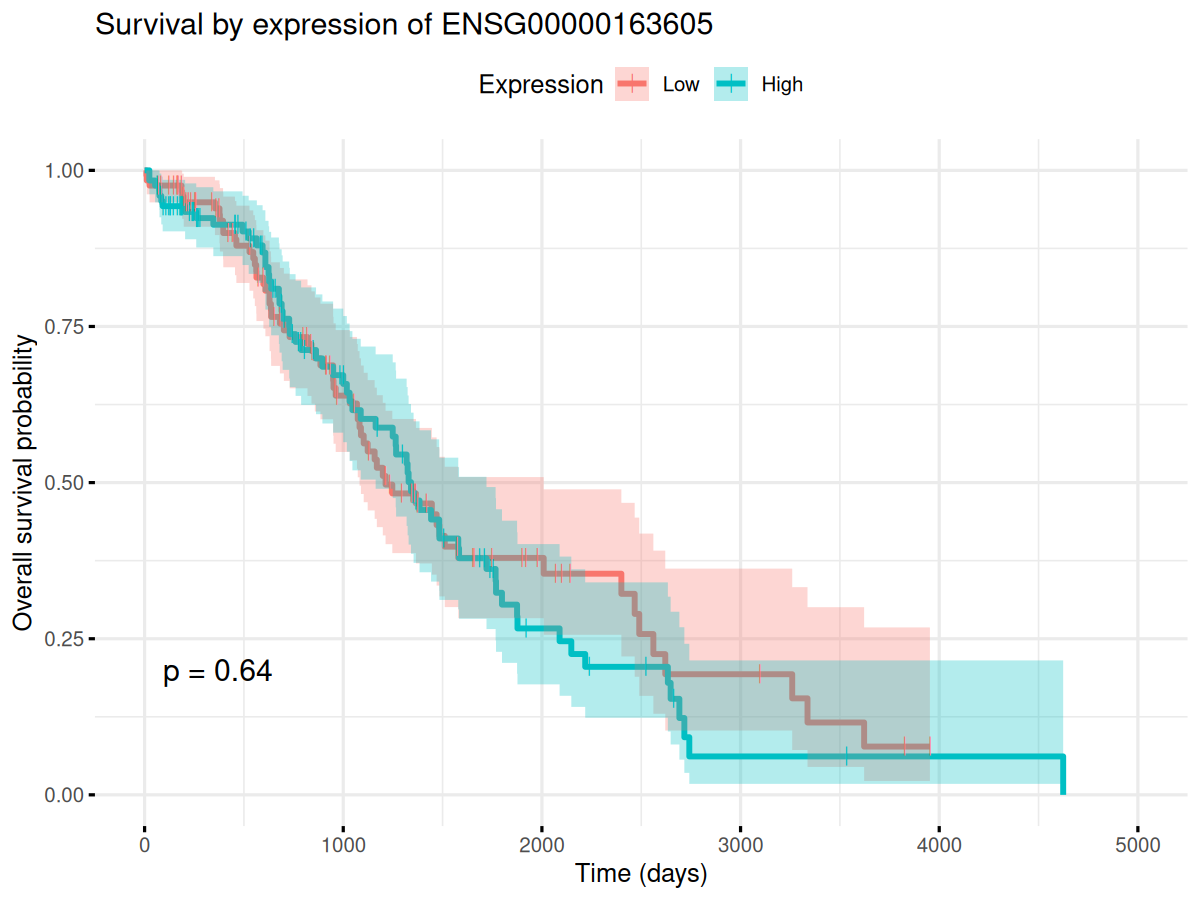


Cox PH summary (High vs Low):
Call:
coxph(formula = surv_obj ~ expr_group, data = df0)

  n= 246, number of events= 127 

                  coef exp(coef) se(coef)     z Pr(>|z|)
expr_groupHigh 0.08451   1.08818  0.17885 0.472    0.637

               exp(coef) exp(-coef) lower .95 upper .95
expr_groupHigh     1.088      0.919    0.7664     1.545

Concordance= 0.5  (se = 0.026 )
Likelihood ratio test= 0.22  on 1 df,   p=0.6
Wald test            = 0.22  on 1 df,   p=0.6
Score (logrank) test = 0.22  on 1 df,   p=0.6

        Variable    HR              CI p.value
1 expr_groupHigh 1.088 (0.766 – 1.545)   0.637


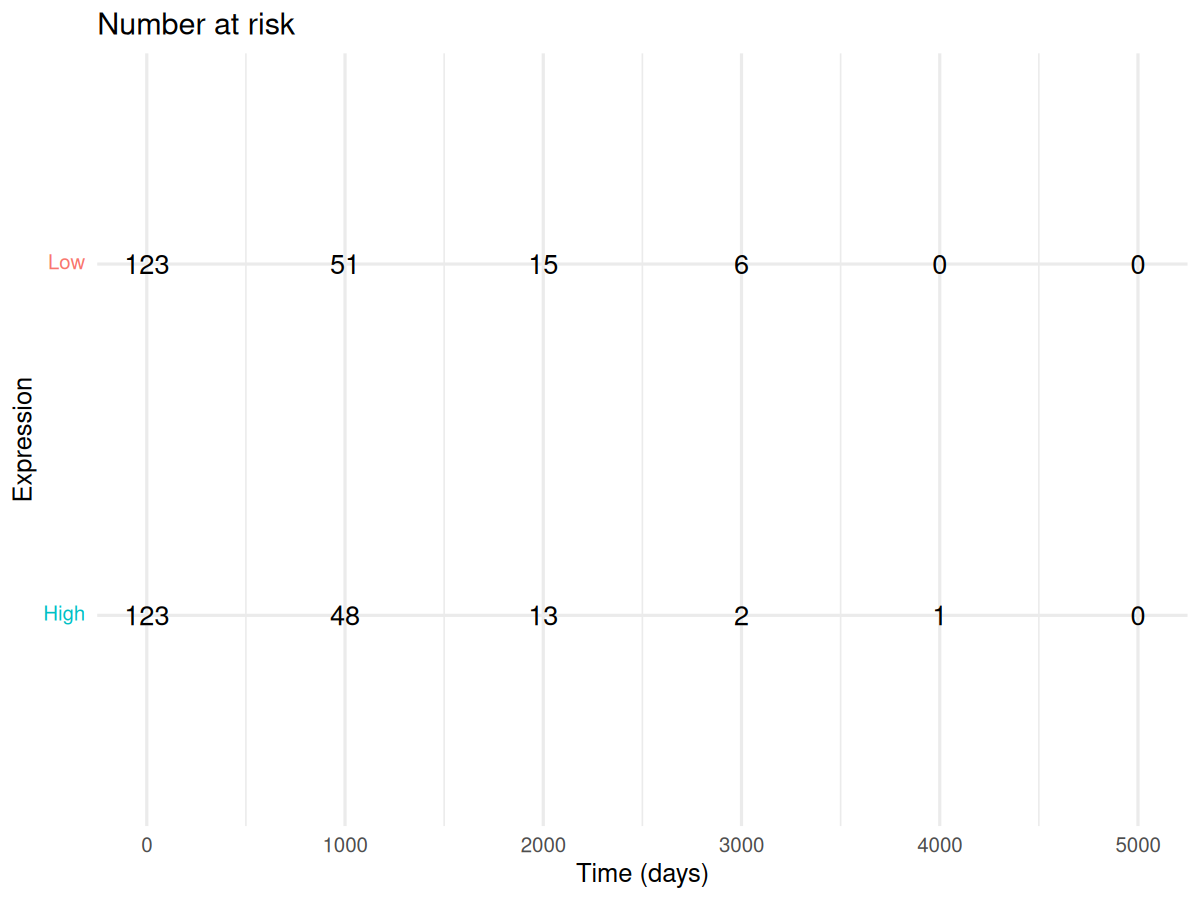


Median survival by group:
           strata median lower upper
1  expr_group=Low   1213  1082  2009
2 expr_group=High   1341  1163  1721

Test proportional hazards assumptions
           chisq df   p
expr_group   1.1  1 0.3
GLOBAL       1.1  1 0.3


pdf 
  2


--- Scaled Schoenfeld Residuals (transform = 'identity') ---
           chisq df    p
expr_group 0.397  1 0.53
GLOBAL     0.397  1 0.53


pdf 
  2

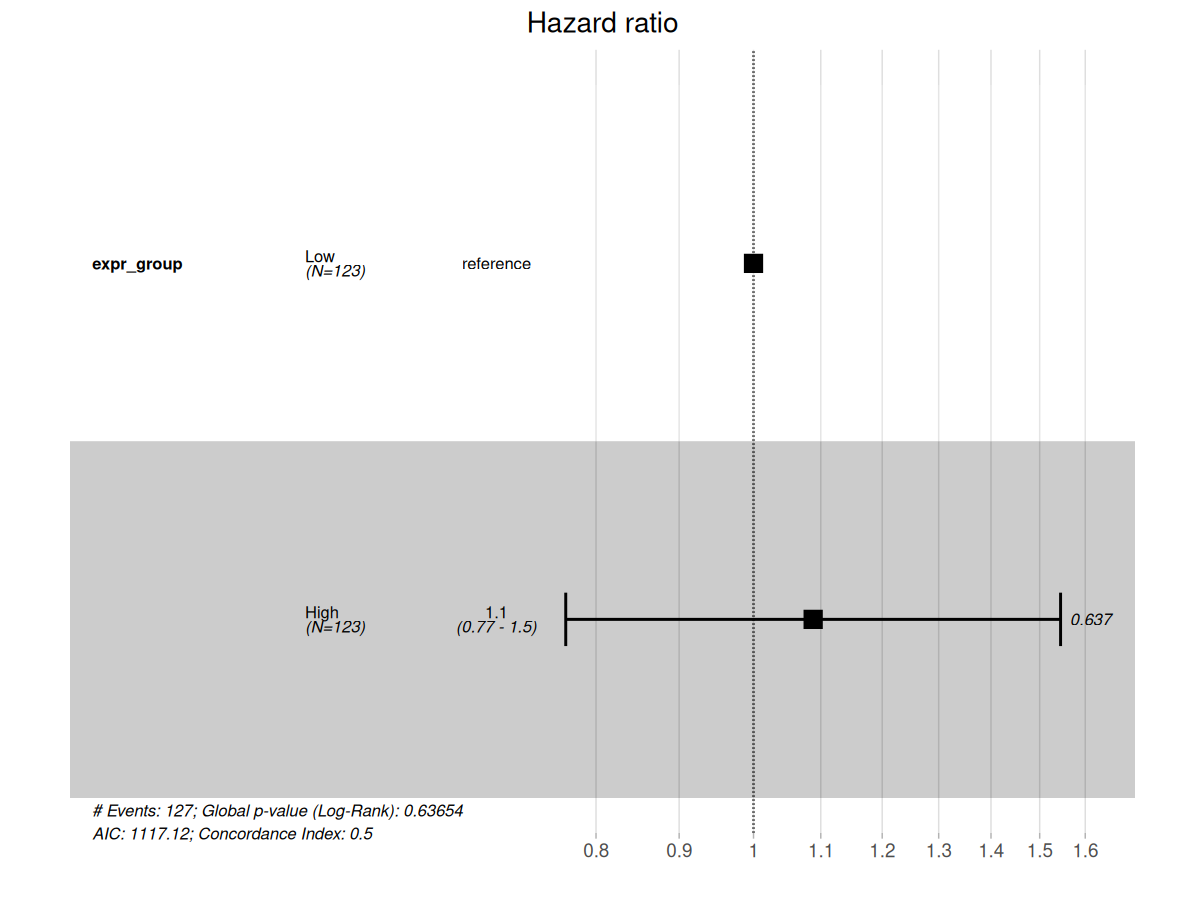

pdf 
  2


C-index (concordance): 0.5 


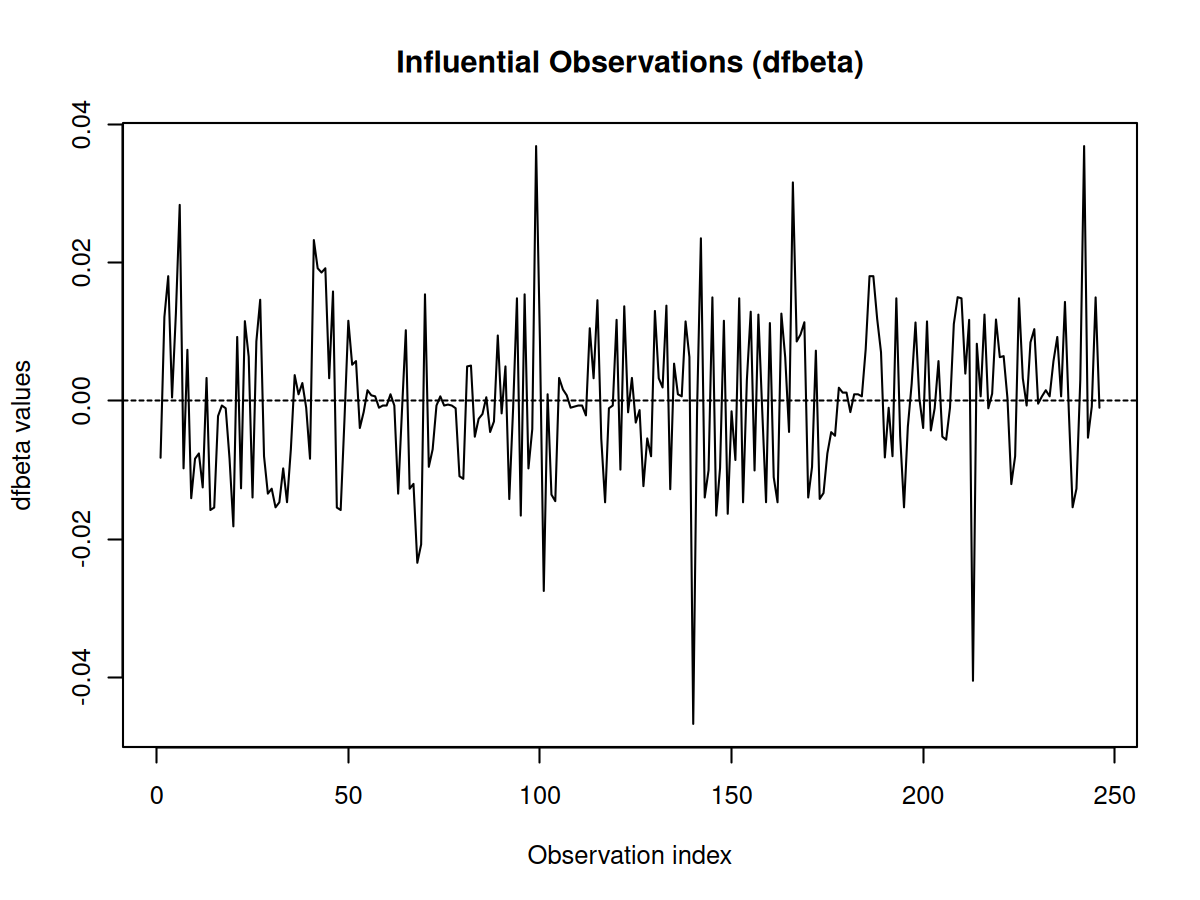

In [52]:
# ---- Display options (Jupyter/RMarkdown) ----
options(repr.plot.width = 8, repr.plot.height = 6, repr.plot.res = 150)

# ---- Packages ----
library(dplyr)
library(survival)
library(survminer)
library(ggplot2)

# ---- Gene of interest ----
gene_to_test <- "ENSG00000163605"
gene_to_test <- gsub("[^[:alnum:]_.-]", "_", gene_to_test)  # safe for filenames

# ---- Sanity checks ----
stopifnot(gene_to_test %in% colnames(df))
stopifnot(all(c("time","vital_status_bin") %in% colnames(df)))

# ---- Filter to rows actually used in survival analysis ----
df0 <- df %>%
  filter(!is.na(time), !is.na(vital_status_bin), !is.na(.data[[gene_to_test]]))

cat("N with valid survival & gene values:", nrow(df0), "\n")
print(summary(df0[[gene_to_test]]))

# ---- Define cutoffs (tertiles) on the ANALYSIS subset ----
if (!exists("cutoff_high") || !exists("cutoff_low") ||
    is.na(cutoff_high) || is.na(cutoff_low)) {
  qs <- quantile(df0[[gene_to_test]], probs = c(0.33, 0.67), na.rm = TRUE, type = 1)
  cutoff_low  <- qs[1]
  cutoff_high <- qs[2]
}
cat("Cutoff low:", cutoff_low, " | Cutoff high:", cutoff_high, "\n")

# ---- Create expression groups ----
df0 <- df0 %>%
  mutate(
    expr_group = case_when(
      .data[[gene_to_test]] >= cutoff_high ~ "High",
      .data[[gene_to_test]] <= cutoff_low  ~ "Low",
      TRUE ~ NA_character_
    )
  ) %>%
  filter(!is.na(expr_group)) %>%
  mutate(expr_group = factor(expr_group, levels = c("Low","High")))

cat("N after grouping:", nrow(df0), "\n"); print(table(df0$expr_group))

# Guard against degenerate splits
stopifnot(length(unique(df0$expr_group)) == 2 && all(table(df0$expr_group) > 0))

# ---- Survival objects ----
surv_obj <- Surv(time = df0$time, event = df0$vital_status_bin)

# ---- KM + explicit log-rank ----
fit <- survfit(surv_obj ~ expr_group, data = df0)
logrank_test <- survdiff(surv_obj ~ expr_group, data = df0)
p_logrank <- 1 - pchisq(logrank_test$chisq, length(logrank_test$n) - 1)
cat("\nLog-rank p-value:", signif(p_logrank, 4), "\n")

km_plot <- ggsurvplot(
  fit, data = df0, pval = TRUE, conf.int = TRUE,
  risk.table = TRUE, risk.table.height = 0.22,
  censor.shape = 124, censor.size = 3,
  xlab = "Time (days)", ylab = "Overall survival probability",
  title = paste("Survival by expression of", gene_to_test),
  legend.title = "Expression", legend.labs = c("Low","High"),
  ggtheme = theme_minimal(base_size = 12)
)
print(km_plot$plot); print(km_plot$table)

ggsave(paste0(gene_to_test, "_KM_plot_expression.jpg"),
       plot = km_plot$plot, width = 8, height = 6, dpi = 300)
ggsave(paste0(gene_to_test, "_KM_plot_risktable.jpg"),
       plot = km_plot$table, width = 8, height = 3, dpi = 300)

# ---- Cox PH + forest ----
cox_fit <- coxph(surv_obj ~ expr_group, data = df0)
cox_summary <- summary(cox_fit)
cat("\nCox PH summary (High vs Low):\n"); print(cox_summary)

hr       <- cox_summary$coefficients[1, "exp(coef)"]
p_cox    <- cox_summary$coefficients[1, "Pr(>|z|)"]
ci_lo    <- cox_summary$conf.int[1, "lower .95"]
ci_hi    <- cox_summary$conf.int[1, "upper .95"]

cox_results <- data.frame(
  Variable = rownames(cox_summary$coefficients)[1],
  HR = round(hr, 3),
  CI = sprintf("(%0.3f – %0.3f)", ci_lo, ci_hi),
  p.value = signif(p_cox, 3)
)
print(cox_results)

forest <- ggforest(cox_fit, data = df0)
print(forest)
ggsave(paste0(gene_to_test, "_cox_forest.png"),
       plot = forest, width = 7, height = 5, dpi = 300)

# ---- Median survival by group ----
cat("\nMedian survival by group:\n"); print(surv_median(fit))

# ---- PH diagnostics (Schoenfeld) ----
cat("\nTest proportional hazards assumptions\n")
ph_test <- cox.zph(cox_fit)
print(ph_test)

# Save panel with a proper outer title
png(paste0(gene_to_test, "_schoenfeld_residuals.png"),
    width = 8, height = 6, units = "in", res = 300)
op <- par(no.readonly = TRUE); par(oma = c(0, 0, 2.2, 0))
plot(ph_test)
mtext("Schoenfeld Residuals Test", outer = TRUE, line = 0.8, cex = 1.1)
par(op); dev.off()

cat("\n--- Scaled Schoenfeld Residuals (transform = 'identity') ---\n")
scaled_ph_test <- cox.zph(cox_fit, transform = "identity")
print(scaled_ph_test)

png(paste0(gene_to_test, "_schoenfeld_residuals_scaled.png"),
    width = 8, height = 6, units = "in", res = 300)
op <- par(no.readonly = TRUE); par(oma = c(0, 0, 2.2, 0))
plot(scaled_ph_test)
mtext("Scaled Schoenfeld Residuals (identity transform)", outer = TRUE, line = 0.8, cex = 1.1)
par(op); dev.off()

# ---- Influential observations (dfbeta) ----
dfbeta_vals <- residuals(cox_fit, type = "dfbeta")
matplot(dfbeta_vals, type = "l", lty = 1,
        main = "Influential Observations (dfbeta)",
        xlab = "Observation index", ylab = "dfbeta values")
abline(h = 0, lty = 2)

png(paste0(gene_to_test, "_dfbeta_influential.png"),
    width = 8, height = 6, units = "in", res = 300)
matplot(dfbeta_vals, type = "l", lty = 1,
        main = paste("Influential Observations (dfbeta) -", gene_to_test),
        xlab = "Observation index", ylab = "dfbeta values")
abline(h = 0, lty = 2)
dev.off()

# ---- Model fit (concordance) ----
c_index <- cox_summary$concordance[1]
cat("\nC-index (concordance):", round(c_index, 3), "\n")


In [53]:
dim(merged_df)
dim(df)

# ?Surv
# ?survfit
# ?survdiff
# ?coxph
# ?cox.zph

# cat("the cox object\n")
# cox_fit
# cat("\nsummary of cox\n")
# summary(cox_fit)
# cat("\nthe structure of cox object\n")
# str(cox_fit)

# survdiff performs a log-rank test (which compares survival curves), it doesn't explicitly fit a Cox proportional hazards model. 
# If you wanted to assess hazard ratios and adjust for covariates, you would use the coxph() function from the survival package.

[1]   372 53516

[1]   372 53516

In [54]:
# scaling on multiple genes 

print("Survival Analysis : all the genes in A2780_targets.txt")

[1] "Survival Analysis : all the genes in A2780_targets.txt"


In [55]:
library(readr)

# Read, trim, drop empties, deduplicate, strip version suffixes like ".12"

genes <- read_lines("A2780_targets.txt", progress = FALSE)
genes <- unique(trimws(genes))
genes <- genes[nzchar(genes)]
genes <- sub("\\.[0-9]+$", "", genes)  # ENSG00000149948.12 -> ENSG00000149948

# Check which are present in your data frame 'df' (genes are columns)
genes_present <- intersect(genes, colnames(df))
genes_missing <- setdiff(genes, colnames(df))
cat("Present:", length(genes_present), " | Missing:", length(genes_missing), "\n")
if (length(genes_missing)) writeLines(genes_missing, "missing_genes.txt")


Present: 4207  | Missing: 117 


In [56]:
gene_list = genes_present
# print(gene_list)
print(paste("Number of genes:", length(gene_list)))

[1] "Number of genes: 4207"


In [57]:
# To be continued in a script that loops over each gene ! 

In [58]:
# Prepare expression data
# plan(multisession)  # use parallel processing

In [59]:
# Other functions :
# https://bioconductor.org/packages/release/bioc/vignettes/TCGAbiolinks/inst/doc/analysis.html

# TCGAanalyze: Analyze data from TCGA.
# TCGAanalyze_Preprocessing: Preprocessing of Gene Expression data (IlluminaHiSeq_RNASeqV2)

# TCGAanalyze_DEA & TCGAanalyze_LevelTab: Differential expression analysis (DEA)
# TCGAanalyze_EAcomplete & TCGAvisualize_EAbarplot: Enrichment Analysis

# TCGAanalyze_survival: Survival Analysis
# TCGAanalyze_SurvivalKM: Correlating gene expression and Survival Analysis
# TCGAanalyze_DMR: Differentially methylated regions Analysis

# TCGAvisualize_Heatmap: Create heatmaps with cluster bars
# TCGAvisualize_Volcano: Create volcano plot
# TCGAvisualize_PCA: Principal Component Analysis plot for differentially expressed genes
# TCGAvisualize_meanMethylation: Mean DNA Methylation Analysis

# TCGAvisualize_starburst: Integration of gene expression and DNA methylation data